In [1]:
import pandas as pd
import numpy as np
#!pip install BorutaShap xgboost
#!pip install scipy==1.11.4
#!pip install optuna

In [2]:
df = pd.read_csv('datos_finales.csv', low_memory=False)

In [3]:
print(df.columns.size)

434


In [4]:
df['ROUND'].unique()

array([5, 6, 7, 8, 9, 3, 4, 0, 2, 1], dtype=int64)

In [5]:
# Aplicamos validación Walkforward, con ventanas de entreno de 5 años y probamos en el año siguiente. Ej: entrenamos 2012-2016, probamos 2017

# Ventana de años para la validación
window = 5
# Años disponibles en los datos
years = sorted(df['YEAR'].unique())
# Conjunto de datos de entrenamiento
train_df = df[df['YEAR'] < 2023]        

# Variables no predictoras (sin valor útil o que aportan datos del resultado del partido)
non_predictor_cols = ['TOURNEY_ID','TOURNEY_NAME','MATCH_ID','DRAW_SIZE','TOURNEY_DATE','SCORE','MINUTES','COMMENT','UPSET','ACE_FAVOURITE',
                      'ACE_UNDERDOG','DF_FAVOURITE','DF_UNDERDOG','SVPT_FAVOURITE','SVPT_UNDERDOG','1STIN_FAVOURITE','1STIN_UNDERDOG',
                      '1STWON_FAVOURITE','1STWON_UNDERDOG','2NDWON_FAVOURITE','2NDWON_UNDERDOG','SVGMS_FAVOURITE','SVGMS_UNDERDOG', 'YEAR',
                      'BPSAVED_FAVOURITE','BPSAVED_UNDERDOG','BPFACED_FAVOURITE','BPFACED_UNDERDOG','1_FAVOURITE','1_UNDERDOG','2_FAVOURITE',
                      '2_UNDERDOG','3_FAVOURITE','3_UNDERDOG','4_FAVOURITE','4_UNDERDOG','5_FAVOURITE','5_UNDERDOG','SETS_FAVOURITE', 'ID_FAVOURITE',
                      'SETS_UNDERDOG','B365_FAVOURITE','B365_UNDERDOG','PS_FAVOURITE','PS_UNDERDOG','SURFACE','ACE_PER_SERVE_FAVOURITE',
                      'ACE_PER_SERVE_UNDERDOG','DF_PER_SERVE_FAVOURITE','DF_PER_SERVE_UNDERDOG','BPSAVED_PERCENTAGE_FAVOURITE', 'ID_UNDERDOG',
                      'BPSAVED_PERCENTAGE_UNDERDOG','BPFACED_PER_SVGM_FAVOURITE','BPFACED_PER_SVGM_UNDERDOG','NAME_FAVOURITE','NAME_UNDERDOG','COURT',
                      'BP_CONVERTED_FAVOURITE','BP_CONVERTED_UNDERDOG','BP_CONVERTED_PCT_FAVOURITE','BP_CONVERTED_PCT_UNDERDOG',
                      'BREAKS_PER_SVGM_FAVOURITE','BREAKS_PER_SVGM_UNDERDOG','RETURN_PTS_WON_FAVOURITE','RETURN_PTS_WON_UNDERDOG',
                      '2ND_SERVES_FAVOURITE','RETURN_PTS_WON_PCT_FAVOURITE','RETURN_PTS_WON_PCT_UNDERDOG','RETURN_2ND_WON_PCT_FAVOURITE',
                      'RETURN_2ND_WON_PCT_UNDERDOG','2ND_SERVES_UNDERDOG','RETURN_2ND_WON_FAVOURITE','RETURN_2ND_WON_UNDERDOG',
                      'TOTAL_GAMES_WON_FAVOURITE','TOTAL_GAMES_WON_UNDERDOG','TOTAL_GAMES','GAMES_WON_PCT_FAVOURITE','GAMES_WON_PCT_UNDERDOG']
# Variables predictoras
predictor_cols = [col for col in df.columns if col not in non_predictor_cols]
# Variable objetivo
target = 'UPSET'

In [6]:
print(f'{len(predictor_cols)} columnas predictoras')
print(f'{len(non_predictor_cols)} columnas no predictoras')
len(predictor_cols)+len(non_predictor_cols)

355 columnas predictoras
79 columnas no predictoras


434

In [7]:
print(train_df['UPSET'].mean())
print((1 - train_df['UPSET'].mean())/train_df['UPSET'].mean())

0.34483941274740837
1.8999005422053963


#### Modelo RandomForest básico con todas las variables predictoras

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, average_precision_score, precision_score, recall_score, accuracy_score

logloss_history = []
aucpr_history = []
precision_history = []
recall_history = []
accuracy_history = []

for i in range(len(years) - window - 4):
    # Define los años sobre los que trabajar 
    train_start = years[i]
    train_end = years[i + window - 1]
    test_year = years[i + window]
    print(f"Entrenando: {train_start}-{train_end} | Testeando: {test_year}")
    
    # Obtiene los partidos jugados en los años de interés
    train_df = df[(df['YEAR'] >= train_start) & (df['YEAR'] <= train_end)]
    test_df = df[df['YEAR'] == test_year]

    # Variables predictoras y objetivo de los partidos de interés
    X_train, y_train = train_df[predictor_cols], train_df[target]
    X_test, y_test = test_df[predictor_cols], test_df[target]
    
    # Entrena el modelo
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)
    
    # Predice (Usamos predict_proba para ver la confianza del modelo). probas[:, 1] es la probabilidad de que la clase sea 1
    probabilidades = model.predict_proba(X_test)[:, 1]
    class_predictions = model.predict(X_test)
    
    metric_logloss = log_loss(y_test, probabilidades)
    metric_aucpr = average_precision_score(y_test, probabilidades)
    metric_precision = precision_score(y_test, class_predictions, zero_division=0)
    metric_recall = recall_score(y_test, class_predictions, zero_division=0)
    metric_accuracy = accuracy_score(y_test, class_predictions)
    
    logloss_history.append(metric_logloss)
    aucpr_history.append(metric_aucpr)
    precision_history.append(metric_precision)
    recall_history.append(metric_recall)
    accuracy_history.append(metric_accuracy)
    print(f"Resultados {test_year} -> LogLoss: {metric_logloss:.4f} | AUCPR: {metric_aucpr:.4f} | Accuracy: {metric_accuracy:.4f} | Precisión: {metric_precision:.4f} | Recall: {metric_recall:.4f}")

print("\n--- MEDIAS RANDOM_FOREST BÁSICO (1990-2022) ---")
print(f"Media LogLoss: {sum(logloss_history)/len(logloss_history):.4f}")
print(f"Media AUCPR:   {sum(aucpr_history)/len(aucpr_history):.4f}")
print(f"Media Accuracy: {sum(accuracy_history)/len(accuracy_history):.4f}")
print(f"Media Precisión: {sum(precision_history)/len(precision_history):.4f}")
print(f"Media Recall: {sum(recall_history)/len(recall_history):.4f}")

Entrenando: 1990-1994 | Testeando: 1995
Resultados 1995 -> LogLoss: 0.6103 | AUCPR: 0.4806 | Accuracy: 0.6676 | Precisión: 0.5429 | Recall: 0.1805
Entrenando: 1991-1995 | Testeando: 1996
Resultados 1996 -> LogLoss: 0.6156 | AUCPR: 0.4493 | Accuracy: 0.6678 | Precisión: 0.5145 | Recall: 0.1569
Entrenando: 1992-1996 | Testeando: 1997
Resultados 1997 -> LogLoss: 0.6169 | AUCPR: 0.4651 | Accuracy: 0.6621 | Precisión: 0.5461 | Recall: 0.1475
Entrenando: 1993-1997 | Testeando: 1998
Resultados 1998 -> LogLoss: 0.6261 | AUCPR: 0.4662 | Accuracy: 0.6556 | Precisión: 0.5394 | Recall: 0.1536
Entrenando: 1994-1998 | Testeando: 1999
Resultados 1999 -> LogLoss: 0.6288 | AUCPR: 0.4904 | Accuracy: 0.6444 | Precisión: 0.5758 | Recall: 0.1580
Entrenando: 1995-1999 | Testeando: 2000
Resultados 2000 -> LogLoss: 0.6246 | AUCPR: 0.4698 | Accuracy: 0.6537 | Precisión: 0.5420 | Recall: 0.1385
Entrenando: 1996-2000 | Testeando: 2001
Resultados 2001 -> LogLoss: 0.6287 | AUCPR: 0.4882 | Accuracy: 0.6461 | Precis

| Periodo Tiempo | Variables | Logloss | AUCPR | Accuracy | Precisión | Recall |
|-|-|-|-|-|-|-|
| 2007-2022 | Todas (355) | 0.6010 | 0.4773 | 0.6725 | 0.5548 | 0.1672 |

#### SELECCIÓN DE VARIABLES: Usamos BorutaShap en los años [1990,2006] para obtener las variables que aportan información al modelo (con el hardware actual, no es computacionalmente razonable aplicar este proceso a cada ventana de entrenamiento). Llamaremos a estas variables golden_cols

c:\Python3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Seleccionando variables...
Warning there are missing values in your data !


100%|██████████| 50/50 [07:28<00:00,  8.98s/it]


39 attributes confirmed important: ['UND_GAMES_WON_PCT_SURFACE_5', 'FAV_BPFACED_PER_SVGM_LAST_3', 'UND_RETURN_PTS_WON_PCT_SURFACE_3', 'RATIO_RANK', 'FAV_GAMES_WON_PCT_LAST_3', 'FAV_GAMES_WON_PCT_LAST_10', 'FAV_H2H_WON_LAST_10', 'AGE_UNDERDOG', 'FAV_H2H_WON_SURFACE_3', 'DIFF_AGE', 'UND_GAMES_WON_PCT_SURFACE_10', 'FAV_RETURN_PTS_WON_PCT_SURFACE_10', 'UND_GAMES_WON_PCT_LAST_3', 'UND_GAMES_WON_PCT_SURFACE_3', 'FAV_BPFACED_PER_SVGM_LAST_1', 'FAV_GAMES_WON_PCT_SURFACE_3', 'FAV_H2H_WON_SURFACE_10', 'FAV_ACE_PER_SERVE_LAST_3', 'FAV_WON_SURFACE_10', 'FAV_H2H_WON_LAST_5', 'FAV_GAMES_WON_PCT_SURFACE_10', 'FAV_2NDWON_SURFACE_10', 'UND_ACE_PER_SERVE_LAST_3', 'FAV_BPFACED_PER_SVGM_LAST_5', 'FAV_DF_PER_SERVE_LAST_10', 'UND_GAMES_WON_PCT_LAST_10', 'HT_UNDERDOG', 'UND_ACE_PER_SERVE_SURFACE_1', 'UND_BPFACED_PER_SVGM_LAST_3', 'UND_BPFACED_PER_SVGM_LAST_5', 'UND_GAMES_WON_PCT_LAST_5', 'AGE_FAVOURITE', 'FAV_GAMES_WON_PCT_SURFACE_5', 'FAV_ACE_PER_SERVE_SURFACE_5', 'FAV_H2H_WON_LAST_3', 'FAV_ACE_PER_SERVE_SU

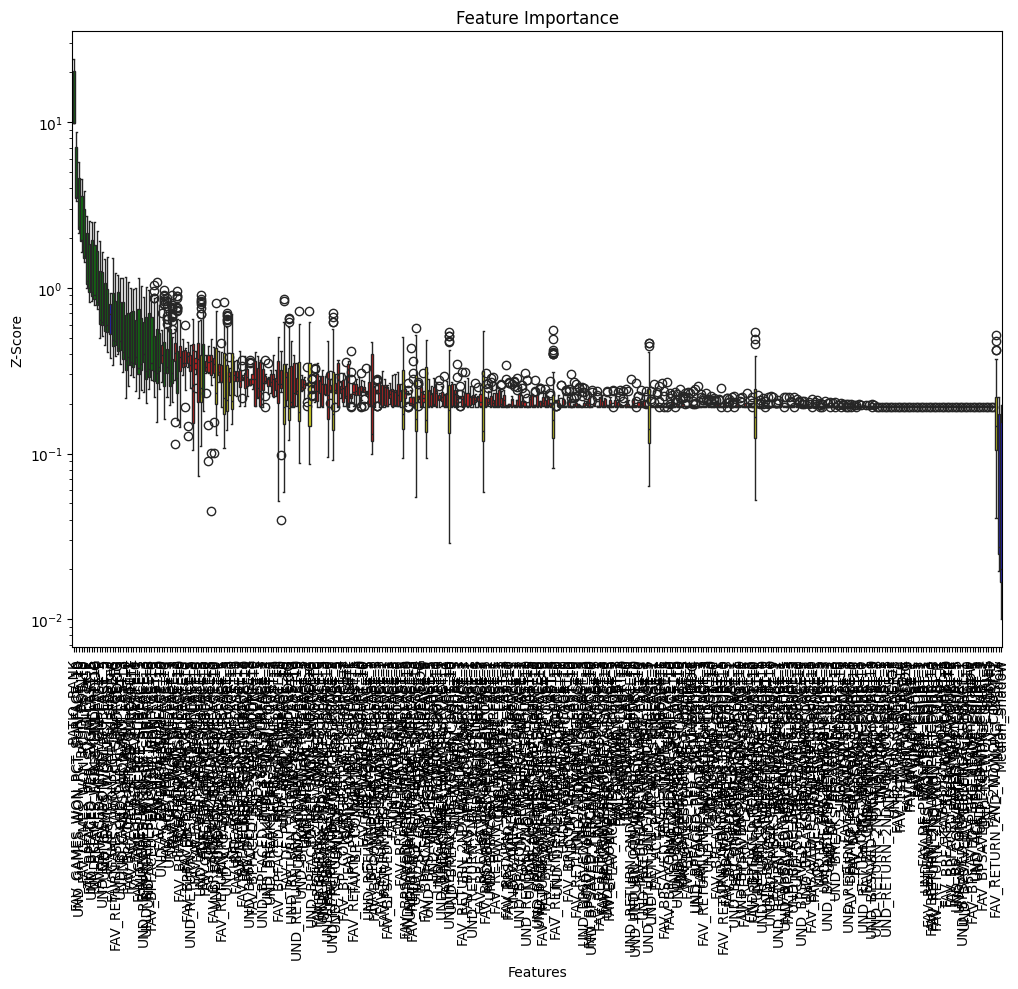


--- RESULTADOS ---
Variables iniciales: 355
Variables aceptadas: 39
Lista definitiva para tu modelo:
Variables aceptadas: ['UND_GAMES_WON_PCT_SURFACE_5', 'FAV_BPFACED_PER_SVGM_LAST_3', 'UND_RETURN_PTS_WON_PCT_SURFACE_3', 'RATIO_RANK', 'FAV_GAMES_WON_PCT_LAST_3', 'FAV_GAMES_WON_PCT_LAST_10', 'FAV_H2H_WON_LAST_10', 'AGE_UNDERDOG', 'FAV_H2H_WON_SURFACE_3', 'DIFF_AGE', 'UND_GAMES_WON_PCT_SURFACE_10', 'FAV_RETURN_PTS_WON_PCT_SURFACE_10', 'UND_GAMES_WON_PCT_LAST_3', 'UND_GAMES_WON_PCT_SURFACE_3', 'FAV_BPFACED_PER_SVGM_LAST_1', 'FAV_GAMES_WON_PCT_SURFACE_3', 'FAV_H2H_WON_SURFACE_10', 'FAV_ACE_PER_SERVE_LAST_3', 'FAV_WON_SURFACE_10', 'FAV_H2H_WON_LAST_5', 'FAV_GAMES_WON_PCT_SURFACE_10', 'FAV_2NDWON_SURFACE_10', 'UND_ACE_PER_SERVE_LAST_3', 'FAV_BPFACED_PER_SVGM_LAST_5', 'FAV_DF_PER_SERVE_LAST_10', 'UND_GAMES_WON_PCT_LAST_10', 'HT_UNDERDOG', 'UND_ACE_PER_SERVE_SURFACE_1', 'UND_BPFACED_PER_SVGM_LAST_3', 'UND_BPFACED_PER_SVGM_LAST_5', 'UND_GAMES_WON_PCT_LAST_5', 'AGE_FAVOURITE', 'FAV_GAMES_WON_PC

In [9]:
from BorutaShap import BorutaShap
from xgboost import XGBClassifier

# Usa una ventana de años grande para hacer un estudio de selección de variables
df_boruta = df[(df['YEAR'] >= 1990) & (df['YEAR'] <= 2006)]
X_boruta = df_boruta[predictor_cols]
y_boruta = df_boruta['UPSET']

# Define un modelo XGBoost básico rápido
basic_model = XGBClassifier(
    max_depth = 4, 
    learning_rate = 0.05, 
    n_estimators = 100, 
    random_state = 42,
    tree_method = 'hist',
    n_jobs = -1
)

# Inicializa BorutaShap
selector = BorutaShap(
    model = basic_model,
    importance_measure = 'shap',
    classification = True
)

# Entrena el algoritmo de supervivencia
# n_trials=50 es el número de veces que repetirá el proceso
print("Seleccionando variables...")
selector.fit(X=X_boruta, y=y_boruta, n_trials=50, random_state=42)

# Visualiza la purga de variables (Gráfico)
selector.plot(X_size=10, figsize=(12, 8), y_scale='log')

# Extrae las variables seleccionadas
golden_cols = selector.Subset().columns.tolist()
golden_tentative_cols = selector.Subset(tentative=True).columns.tolist()

print("\n--- RESULTADOS ---")
print(f"Variables iniciales: {X_boruta.shape[1]}")
print(f"Variables aceptadas: {len(golden_cols)}")
print("Lista definitiva para tu modelo:")
print(f'Variables aceptadas: {golden_cols}')
print(f'Variables aceptadas y dudosas: {golden_tentative_cols}')

In [10]:
golden_cols = ['HT_UNDERDOG','FAV_BPFACED_PER_SVGM_SURFACE_10','UND_BPFACED_PER_SVGM_LAST_5','FAV_GAMES_WON_PCT_SURFACE_10',
               'FAV_GAMES_WON_PCT_SURFACE_3','UND_GAMES_WON_PCT_LAST_3','AGE_FAVOURITE','FAV_RETURN_PTS_WON_PCT_SURFACE_10',
               'UND_ACE_PER_SERVE_SURFACE_1','FAV_H2H_WON_LAST_5','FAV_H2H_WON_LAST_10','FAV_BPFACED_PER_SVGM_LAST_5','FAV_GAMES_WON_PCT_LAST_3',
               'UND_BPFACED_PER_SVGM_LAST_3','UND_GAMES_WON_PCT_LAST_10','FAV_BPFACED_PER_SVGM_LAST_3','FAV_ACE_PER_SERVE_SURFACE_5',
               'FAV_H2H_WON_LAST_3','UND_BPFACED_PER_SVGM_SURFACE_10','UND_GAMES_WON_PCT_SURFACE_3','FAV_DF_PER_SERVE_LAST_10',
               'FAV_ACE_PER_SERVE_SURFACE_3','UND_RETURN_PTS_WON_PCT_SURFACE_3','DIFF_AGE','FAV_GAMES_WON_PCT_SURFACE_5','FAV_ACE_PER_SERVE_LAST_3',
               'FAV_WON_SURFACE_10','FAV_BPFACED_PER_SVGM_LAST_1','UND_GAMES_WON_PCT_SURFACE_10','UND_GAMES_WON_PCT_LAST_5','AGE_UNDERDOG',
               'FAV_H2H_WON_SURFACE_10','UND_ACE_PER_SERVE_LAST_3','FAV_2NDWON_SURFACE_10','FAV_H2H_WON_SURFACE_3','FAV_GAMES_WON_PCT_LAST_10',
               'RATIO_POINTS','UND_GAMES_WON_PCT_SURFACE_5','RATIO_RANK']
golden_tentative_cols = ['FAV_RETURN_2ND_WON_PCT_LAST_1','UND_RETURN_2ND_WON_PCT_SURFACE_5','RANK_UNDERDOG','FAV_DF_PER_SERVE_LAST_5',
                         'UND_ACE_PER_SERVE_SURFACE_3','UND_1STIN_LAST_5','FAV_2NDWON_SURFACE_3','RANK_POINTS_UNDERDOG','UND_ACE_PER_SERVE_SURFACE_5',
                         'FAV_GAMES_WON_PCT_LAST_5','UND_BPFACED_PER_SVGM_LAST_10','FAV_BPFACED_PER_SVGM_SURFACE_5','UND_WON_SURFACE_10',
                         'UND_ACE_PER_SERVE_SURFACE_10','UND_RETURN_PTS_WON_PCT_LAST_10','FAV_RETURN_PTS_WON_PCT_LAST_10','UND_ACE_PER_SERVE_LAST_5',
                         'FAV_1STIN_SURFACE_10','UND_RETURN_2ND_WON_PCT_SURFACE_3'] + golden_cols

In [11]:
print(len(golden_cols))
print(len(golden_tentative_cols))

39
58


#### Modelo RandomForest básico con golden_cols

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, average_precision_score, precision_score, recall_score, accuracy_score

logloss_history = []
aucpr_history = []
precision_history = []
recall_history = []
accuracy_history = []

for i in range(len(years) - window - 4):
    # Define los años sobre los que trabajar
    train_start = years[i]
    train_end = years[i + window - 1]
    test_year = years[i + window]

    if test_year > 2006:
        print(f"Entrenando: {train_start}-{train_end} | Testeando: {test_year}")
        
        # Obtiene los partidos jugados en los años de interés
        train_df = df[(df['YEAR'] >= train_start) & (df['YEAR'] <= train_end)]
        test_df = df[df['YEAR'] == test_year]
    
        # Variables predictoras y objetivo de los partidos de interés
        X_train, y_train = train_df[golden_cols], train_df[target]
        X_test, y_test = test_df[golden_cols], test_df[target]
        
        # Entrena el modelo
        model = RandomForestClassifier(random_state=42)
        model.fit(X_train, y_train)
        
        # Predice (Usamos predict_proba para ver la confianza del modelo). probas[:, 1] es la probabilidad de que la clase sea 1
        probabilidades = model.predict_proba(X_test)[:, 1]
        class_predictions = model.predict(X_test)
        
        metric_logloss = log_loss(y_test, probabilidades)
        metric_aucpr = average_precision_score(y_test, probabilidades)
        metric_precision = precision_score(y_test, class_predictions, zero_division=0)
        metric_recall = recall_score(y_test, class_predictions, zero_division=0)
        metric_accuracy = accuracy_score(y_test, class_predictions)
        
        logloss_history.append(metric_logloss)
        aucpr_history.append(metric_aucpr)
        precision_history.append(metric_precision)
        recall_history.append(metric_recall)
        accuracy_history.append(metric_accuracy)
        
        print(f"Resultados {test_year} -> LogLoss: {metric_logloss:.4f} | AUCPR: {metric_aucpr:.4f} | Accuracy: {metric_accuracy:.4f} | Precisión: {metric_precision:.4f} | Recall: {metric_recall:.4f}")

print("\n--- MEDIAS RANDOM_FOREST BÁSICO (CON VARIABLES BORUTA ACEPTADAS) (2007-2022) ---")
print(f"Media LogLoss: {sum(logloss_history)/len(logloss_history):.4f}")
print(f"Media AUCPR:   {sum(aucpr_history)/len(aucpr_history):.4f}")
print(f"Media Accuracy: {sum(accuracy_history)/len(accuracy_history):.4f}")
print(f"Media Precisión: {sum(precision_history)/len(precision_history):.4f}")
print(f"Media Recall: {sum(recall_history)/len(recall_history):.4f}")

Entrenando: 2002-2006 | Testeando: 2007
Resultados 2007 -> LogLoss: 0.5967 | AUCPR: 0.5037 | Accuracy: 0.6760 | Precisión: 0.5646 | Recall: 0.2492
Entrenando: 2003-2007 | Testeando: 2008
Resultados 2008 -> LogLoss: 0.5927 | AUCPR: 0.4894 | Accuracy: 0.6827 | Precisión: 0.5330 | Recall: 0.2776
Entrenando: 2004-2008 | Testeando: 2009
Resultados 2009 -> LogLoss: 0.5801 | AUCPR: 0.4673 | Accuracy: 0.6856 | Precisión: 0.5127 | Recall: 0.2354
Entrenando: 2005-2009 | Testeando: 2010
Resultados 2010 -> LogLoss: 0.5847 | AUCPR: 0.5030 | Accuracy: 0.6902 | Precisión: 0.5745 | Recall: 0.2426
Entrenando: 2006-2010 | Testeando: 2011
Resultados 2011 -> LogLoss: 0.5831 | AUCPR: 0.4743 | Accuracy: 0.6847 | Precisión: 0.5188 | Recall: 0.2430
Entrenando: 2007-2011 | Testeando: 2012
Resultados 2012 -> LogLoss: 0.5771 | AUCPR: 0.5044 | Accuracy: 0.6957 | Precisión: 0.5674 | Recall: 0.2575
Entrenando: 2008-2012 | Testeando: 2013
Resultados 2013 -> LogLoss: 0.5858 | AUCPR: 0.4867 | Accuracy: 0.6793 | Precis

| Periodo Tiempo | Variables | Logloss | AUCPR | Accuracy | Precisión | Recall |
|-|-|-|-|-|-|-|
| 2007-2022 | Todas (355) | 0.6010 | 0.4773 | 0.6725 | 0.5548 | 0.1672 |
| 2007-2022 | BorutaShap (39) | 0.5978 | 0.4841 | 0.6728 | 0.5390 | 0.2341 |

#### Modelo RandomForest básico con golden_tentative_cols

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, average_precision_score, precision_score, recall_score, accuracy_score

logloss_history = []
aucpr_history = []
precision_history = []
recall_history = []
accuracy_history = []

for i in range(len(years) - window - 4):
    # Define los años sobre los que trabajar
    train_start = years[i]
    train_end = years[i + window - 1]
    test_year = years[i + window]

    if test_year > 2006:
        print(f"Entrenando: {train_start}-{train_end} | Testeando: {test_year}")
        
        # Obtiene los partidos jugados en los años de interés
        train_df = df[(df['YEAR'] >= train_start) & (df['YEAR'] <= train_end)]
        test_df = df[df['YEAR'] == test_year]
    
        # Variables predictoras y objetivo de los partidos de interés
        X_train, y_train = train_df[golden_tentative_cols], train_df[target]
        X_test, y_test = test_df[golden_tentative_cols], test_df[target]
        
        # Entrena el modelo
        model = RandomForestClassifier(random_state=42)
        model.fit(X_train, y_train)
        
        # Predice (Usamos predict_proba para ver la confianza del modelo). probas[:, 1] es la probabilidad de que la clase sea 1
        probabilidades = model.predict_proba(X_test)[:, 1]
        class_predictions = model.predict(X_test)
        
        metric_logloss = log_loss(y_test, probabilidades)
        metric_aucpr = average_precision_score(y_test, probabilidades)
        metric_precision = precision_score(y_test, class_predictions, zero_division=0)
        metric_recall = recall_score(y_test, class_predictions, zero_division=0)
        metric_accuracy = accuracy_score(y_test, class_predictions)
        
        logloss_history.append(metric_logloss)
        aucpr_history.append(metric_aucpr)
        precision_history.append(metric_precision)
        recall_history.append(metric_recall)
        accuracy_history.append(metric_accuracy)
        
        print(f"Resultados {test_year} -> LogLoss: {metric_logloss:.4f} | AUCPR: {metric_aucpr:.4f} | Accuracy: {metric_accuracy:.4f} | Precisión: {metric_precision:.4f} | Recall: {metric_recall:.4f}")

print("\n--- MEDIAS RANDOM_FOREST BÁSICO (CON VARIABLES BORUTA ACEPTADAS Y DUDOSAS) (2007-2022) ---")
print(f"Media LogLoss: {sum(logloss_history)/len(logloss_history):.4f}")
print(f"Media AUCPR:   {sum(aucpr_history)/len(aucpr_history):.4f}")
print(f"Media Accuracy: {sum(accuracy_history)/len(accuracy_history):.4f}")
print(f"Media Precisión: {sum(precision_history)/len(precision_history):.4f}")
print(f"Media Recall: {sum(recall_history)/len(recall_history):.4f}")

Entrenando: 2002-2006 | Testeando: 2007
Resultados 2007 -> LogLoss: 0.5978 | AUCPR: 0.5003 | Accuracy: 0.6746 | Precisión: 0.5629 | Recall: 0.2372
Entrenando: 2003-2007 | Testeando: 2008
Resultados 2008 -> LogLoss: 0.5921 | AUCPR: 0.4775 | Accuracy: 0.6834 | Precisión: 0.5392 | Recall: 0.2527
Entrenando: 2004-2008 | Testeando: 2009
Resultados 2009 -> LogLoss: 0.5863 | AUCPR: 0.4630 | Accuracy: 0.6882 | Precisión: 0.5217 | Recall: 0.2378
Entrenando: 2005-2009 | Testeando: 2010
Resultados 2010 -> LogLoss: 0.5867 | AUCPR: 0.4982 | Accuracy: 0.6925 | Precisión: 0.5845 | Recall: 0.2414
Entrenando: 2006-2010 | Testeando: 2011
Resultados 2011 -> LogLoss: 0.5852 | AUCPR: 0.4675 | Accuracy: 0.6855 | Precisión: 0.5229 | Recall: 0.2277
Entrenando: 2007-2011 | Testeando: 2012
Resultados 2012 -> LogLoss: 0.5773 | AUCPR: 0.4999 | Accuracy: 0.6991 | Precisión: 0.5906 | Recall: 0.2333
Entrenando: 2008-2012 | Testeando: 2013
Resultados 2013 -> LogLoss: 0.5900 | AUCPR: 0.4908 | Accuracy: 0.6804 | Precis

| Periodo Tiempo | Variables | Logloss | AUCPR | Accuracy | Precisión | Recall |
|-|-|-|-|-|-|-|
| 2007-2022 | Todas (355) | 0.6010 | 0.4773 | 0.6725 | 0.5548 | 0.1672 |
| 2007-2022 | BorutaShap (39) | 0.5978 | 0.4841 | 0.6728 | 0.5390 | 0.2341 |
| 2007-2022 | BorutaShap (58) | 0.5985 | 0.4839 | 0.6750 | 0.5496 | 0.2254 |

### SELECCIÓN DE MODELOS: Tras ver que no perdemos rendimiento al reducir las variables, pasamos a elegir que modelo usaremos

#### Modelo XGBoost básico (sin pesos) (golden_cols)

In [14]:
import xgboost as xgb
from sklearn.metrics import log_loss, average_precision_score, precision_score, recall_score, accuracy_score

logloss_history = []
aucpr_history = []
precision_history = []
recall_history = []
accuracy_history = []

for i in range(len(years) - window - 4):
    # Define los años sobre los que trabajar (aprendemos 4 años, validamos 1 año, testeamos 1 año)
    train_start = years[i]
    val_year = years[i + window - 1]  # El último año de la ventana de 5 es para validación (early_stopping)
    train_end = val_year - 1
    test_year = years[i + window]

    if test_year > 2006:
        print(f"Entrenando: {train_start}-{train_end} | Testeando: {test_year}")
        
        # Obtiene los partidos jugados en los años de interés
        train_df = df[(df['YEAR'] >= train_start) & (df['YEAR'] <= train_end)]
        val_df = df[df['YEAR'] == val_year]
        test_df = df[df['YEAR'] == test_year]
    
        # Variables predictoras y objetivo de los partidos de interés
        X_train, y_train = train_df[golden_cols], train_df[target]
        X_val, y_val = val_df[golden_cols], val_df[target]
        X_test, y_test = test_df[golden_cols], test_df[target]
        
        # Entrena el modelo
        model_xgb = xgb.XGBClassifier(
            n_estimators = 1000,
            max_depth = 4,             # Buscamos árboles poco profundos
            learning_rate = 0.01,      # Aprendizaje muy pequeño y seguro
            subsample = 0.8,           # Evita que un solo partido raro domine el árbol
            colsample_bytree = 0.8,    # Subconjuntos de las variables predictoras
            random_state = 42,
            tree_method = 'hist',
            early_stopping_rounds = 20 # Si en 20 árboles no mejora, para
        )
        model_xgb.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        # Predice (Usamos predict_proba para ver la confianza del modelo). probas[:, 1] es la probabilidad de que la clase sea 1
        probs = model_xgb.predict_proba(X_test)[:, 1]
        class_predictions = model_xgb.predict(X_test)
        
        metric_logloss = log_loss(y_test, probs)
        metric_aucpr = average_precision_score(y_test, probs)
        metric_precision = precision_score(y_test, class_predictions, zero_division=0)
        metric_recall = recall_score(y_test, class_predictions, zero_division=0)
        metric_accuracy = accuracy_score(y_test, class_predictions)

        logloss_history.append(metric_logloss)
        aucpr_history.append(metric_aucpr)
        precision_history.append(metric_precision)
        recall_history.append(metric_recall)
        accuracy_history.append(metric_accuracy)

        best_trees = model_xgb.best_iteration
        print(f"Resultados {test_year} (Trees: {best_trees:3d}) -> LogLoss: {metric_logloss:.4f} | AUCPR: {metric_aucpr:.4f} | Accuracy: {metric_accuracy:.4f} | Precisión: {metric_precision:.4f} | Recall: {metric_recall:.4f}")

print("\n--- MEDIAS XGBOOST BÁSICO (CON VARIABLES BORUTA ACEPTADAS) (2007-2022) ---")
print(f"Media LogLoss: {sum(logloss_history)/len(logloss_history):.4f}")
print(f"Media AUCPR:   {sum(aucpr_history)/len(aucpr_history):.4f}")
print(f"Media Accuracy: {sum(accuracy_history)/len(accuracy_history):.4f}")
print(f"Media Precisión: {sum(precision_history)/len(precision_history):.4f}")
print(f"Media Recall: {sum(recall_history)/len(recall_history):.4f}")

Entrenando: 2002-2005 | Testeando: 2007
Resultados 2007 (Trees: 426) -> LogLoss: 0.5869 | AUCPR: 0.5357 | Accuracy: 0.6828 | Precisión: 0.6000 | Recall: 0.2312
Entrenando: 2003-2006 | Testeando: 2008
Resultados 2008 (Trees: 517) -> LogLoss: 0.5832 | AUCPR: 0.5094 | Accuracy: 0.6893 | Precisión: 0.5685 | Recall: 0.2266
Entrenando: 2004-2007 | Testeando: 2009
Resultados 2009 (Trees: 562) -> LogLoss: 0.5742 | AUCPR: 0.4807 | Accuracy: 0.6908 | Precisión: 0.5293 | Recall: 0.2529
Entrenando: 2005-2008 | Testeando: 2010
Resultados 2010 (Trees: 431) -> LogLoss: 0.5782 | AUCPR: 0.5242 | Accuracy: 0.6940 | Precisión: 0.5988 | Recall: 0.2254
Entrenando: 2006-2009 | Testeando: 2011
Resultados 2011 (Trees: 524) -> LogLoss: 0.5765 | AUCPR: 0.4842 | Accuracy: 0.6908 | Precisión: 0.5418 | Recall: 0.2359
Entrenando: 2007-2010 | Testeando: 2012
Resultados 2012 (Trees: 402) -> LogLoss: 0.5691 | AUCPR: 0.5166 | Accuracy: 0.7025 | Precisión: 0.5937 | Recall: 0.2598
Entrenando: 2008-2011 | Testeando: 2013


| Tipo de Modelo | Periodo Tiempo | Variables | Logloss | AUCPR | Accuracy | Precisión | Recall |
|-|-|-|-|-|-|-|-|
| RandomForest Básico | 2007-2022 | Todas (355) | 0.6010 | 0.4773 | 0.6725 | 0.5548 | 0.1672 |
| RandomForest Básico | 2007-2022 | BorutaShap (39) | 0.5978 | 0.4841 | 0.6728 | 0.5390 | 0.2341 |
| RandomForest Básico | 2007-2022 | BorutaShap (58) | 0.5985 | 0.4839 | 0.6750 | 0.5496 | 0.2254 |
| XGBoost Básico sin Pesos | 2007-2022 | BorutaShap (39) | 0.5905 | 0.5037 | 0.6781 | 0.5678 | 0.2104 |

#### Modelo XGBoost básico (sin pesos) (golden_tentative_cols)

In [15]:
import xgboost as xgb
from sklearn.metrics import log_loss, average_precision_score, precision_score, recall_score, accuracy_score

logloss_history = []
aucpr_history = []
precision_history = []
recall_history = []
accuracy_history = []

for i in range(len(years) - window - 4):
    # Define los años sobre los que trabajar (aprendemos 4 años, validamos 1 año, testeamos 1 año)
    train_start = years[i]
    val_year = years[i + window - 1]  # El último año de la ventana de 5 es para validación (early_stopping)
    train_end = val_year - 1
    test_year = years[i + window]

    if test_year > 2006:
        print(f"Entrenando: {train_start}-{train_end} | Testeando: {test_year}")
        
        # Obtiene los partidos jugados en los años de interés
        train_df = df[(df['YEAR'] >= train_start) & (df['YEAR'] <= train_end)]
        val_df = df[df['YEAR'] == val_year]
        test_df = df[df['YEAR'] == test_year]
    
        # Variables predictoras y objetivo de los partidos de interés
        X_train, y_train = train_df[golden_tentative_cols], train_df[target]
        X_val, y_val = val_df[golden_tentative_cols], val_df[target]
        X_test, y_test = test_df[golden_tentative_cols], test_df[target]
        
        # Entrena el modelo
        model_xgb_tentative = xgb.XGBClassifier(
            n_estimators = 1000,
            max_depth = 4,             # Buscamos árboles poco profundos
            learning_rate = 0.01,      # Aprendizaje muy pequeño y seguro
            subsample = 0.8,           # Evita que un solo partido raro domine el árbol
            colsample_bytree = 0.8,    # Subconjuntos de las variables predictoras
            random_state = 42,
            tree_method = 'hist',
            early_stopping_rounds = 20 # Si en 20 árboles no mejora, para
        )
        
        model_xgb_tentative.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        # Predice (Usamos predict_proba para ver la confianza del modelo). probas[:, 1] es la probabilidad de que la clase sea 1
        probs = model_xgb_tentative.predict_proba(X_test)[:, 1]
        class_predictions = model_xgb_tentative.predict(X_test)
        
        metric_logloss = log_loss(y_test, probs)
        metric_aucpr = average_precision_score(y_test, probs)
        metric_precision = precision_score(y_test, class_predictions, zero_division=0)
        metric_recall = recall_score(y_test, class_predictions, zero_division=0)
        metric_accuracy = accuracy_score(y_test, class_predictions)

        logloss_history.append(metric_logloss)
        aucpr_history.append(metric_aucpr)
        precision_history.append(metric_precision)
        recall_history.append(metric_recall)
        accuracy_history.append(metric_accuracy)

        best_trees = model_xgb_tentative.best_iteration
        print(f"Resultados {test_year} (Trees: {best_trees:3d}) -> LogLoss: {metric_logloss:.4f} | AUCPR: {metric_aucpr:.4f} | Accuracy: {metric_accuracy:.4f} | Precisión: {metric_precision:.4f} | Precisión: {metric_recall:.4f}")

print("\n--- MEDIAS XGBOOST BÁSICO (VARIABLES BORUTA ACEPTADAS Y DUDOSAS) (2007-2022) ---")
print(f"Media LogLoss: {sum(logloss_history)/len(logloss_history):.4f}")
print(f"Media AUCPR:   {sum(aucpr_history)/len(aucpr_history):.4f}")
print(f"Media Accuracy: {sum(accuracy_history)/len(accuracy_history):.4f}")
print(f"Media Precisión: {sum(precision_history)/len(precision_history):.4f}")
print(f"Media Recall: {sum(recall_history)/len(recall_history):.4f}")

Entrenando: 2002-2005 | Testeando: 2007
Resultados 2007 (Trees: 425) -> LogLoss: 0.5877 | AUCPR: 0.5345 | Accuracy: 0.6839 | Precisión: 0.6042 | Precisión: 0.2322
Entrenando: 2003-2006 | Testeando: 2008
Resultados 2008 (Trees: 645) -> LogLoss: 0.5834 | AUCPR: 0.5043 | Accuracy: 0.6932 | Precisión: 0.5778 | Precisión: 0.2467
Entrenando: 2004-2007 | Testeando: 2009
Resultados 2009 (Trees: 405) -> LogLoss: 0.5743 | AUCPR: 0.4774 | Accuracy: 0.6941 | Precisión: 0.5455 | Precisión: 0.2308
Entrenando: 2005-2008 | Testeando: 2010
Resultados 2010 (Trees: 537) -> LogLoss: 0.5775 | AUCPR: 0.5251 | Accuracy: 0.6963 | Precisión: 0.6017 | Precisión: 0.2403
Entrenando: 2006-2009 | Testeando: 2011
Resultados 2011 (Trees: 551) -> LogLoss: 0.5754 | AUCPR: 0.4885 | Accuracy: 0.6942 | Precisión: 0.5552 | Precisión: 0.2359
Entrenando: 2007-2010 | Testeando: 2012
Resultados 2012 (Trees: 528) -> LogLoss: 0.5688 | AUCPR: 0.5169 | Accuracy: 0.7043 | Precisión: 0.5964 | Precisión: 0.2714
Entrenando: 2008-2011 

| Tipo de Modelo | Periodo Tiempo | Variables | Logloss | AUCPR | Accuracy | Precisión | Recall |
|-|-|-|-|-|-|-|-|
| RandomForest Básico | 2007-2022 | Todas (355) | 0.6010 | 0.4773 | 0.6725 | 0.5548 | 0.1672 |
| RandomForest Básico | 2007-2022 | BorutaShap (39) | 0.5978 | 0.4841 | 0.6728 | 0.5390 | 0.2341 |
| RandomForest Básico | 2007-2022 | BorutaShap (58) | 0.5985 | 0.4839 | 0.6750 | 0.5496 | 0.2254 |
| XGBoost Básico sin Pesos | 2007-2022 | BorutaShap (39) | 0.5905 | 0.5037 | 0.6781 | 0.5678 | 0.2104 |
| XGBoost Básico sin Pesos | 2007-2022 | BorutaShap (58) | 0.5904 | 0.5034 | 0.6786 | 0.5678 | 0.2132 |

#### Modelo XGBoost básico (con pesos y calibrador) (golden_cols)

In [16]:
import xgboost as xgb
from sklearn.metrics import log_loss, average_precision_score, precision_score, recall_score, accuracy_score
from sklearn.calibration import CalibratedClassifierCV, FrozenEstimator

logloss_history = []
aucpr_history = []
precision_history = []
recall_history = []
accuracy_history = []

for i in range(len(years) - window - 4):
    # Define los años sobre los que trabajar (aprendemos 4 años, validamos 1 año, testeamos 1 año)
    train_start = years[i]
    val_year = years[i + window - 1]  # El último año de la ventana de 5 es para validación (early_stopping)
    train_end = val_year - 1
    test_year = years[i + window]

    if test_year > 2006:
        print(f"Entrenando: {train_start}-{train_end} | Testeando: {test_year}")
        
        # Obtiene los partidos jugados en los años de interés
        train_df = df[(df['YEAR'] >= train_start) & (df['YEAR'] <= train_end)]
        val_df = df[df['YEAR'] == val_year]
        test_df = df[df['YEAR'] == test_year]

        # Variables predictoras y objetivo de los partidos de interés
        X_train, y_train = train_df[golden_cols], train_df[target]
        X_val, y_val = val_df[golden_cols], val_df[target]
        X_test, y_test = test_df[golden_cols], test_df[target]

        # Entrena el modelo
        model_xgb_weighted = xgb.XGBClassifier(
            n_estimators = 1000,
            max_depth = 4,             # Buscamos árboles poco profundos
            learning_rate = 0.01,      # Aprendizaje muy pequeño y seguro
            subsample = 0.8,           # Evita que un solo partido raro domine el árbol
            colsample_bytree = 0.8,    # Subconjuntos de las variables predictoras
            random_state = 42,
            tree_method = 'hist',
            scale_pos_weight = 1.90,
            early_stopping_rounds = 20 # Si en 20 árboles no mejora, para
        )

        model_xgb_weighted.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        calibrated_model_xgb = CalibratedClassifierCV(estimator=FrozenEstimator(model_xgb_weighted), method='sigmoid')
        calibrated_model_xgb.fit(X_val, y_val)

        # Predice (Usamos predict_proba para ver la confianza del modelo). probas[:, 1] es la probabilidad de que la clase sea 1
        probs = calibrated_model_xgb.predict_proba(X_test)[:, 1]
        class_predictions = calibrated_model_xgb.predict(X_test)

        metric_logloss = log_loss(y_test, probs)
        metric_aucpr = average_precision_score(y_test, probs)
        metric_precision = precision_score(y_test, class_predictions, zero_division=0)
        metric_recall = recall_score(y_test, class_predictions, zero_division=0)
        metric_accuracy = accuracy_score(y_test, class_predictions)

        logloss_history.append(metric_logloss)
        aucpr_history.append(metric_aucpr)
        precision_history.append(metric_precision)
        recall_history.append(metric_recall)
        accuracy_history.append(metric_accuracy)

        best_trees = model_xgb_weighted.best_iteration
        print(f"Resultados {test_year} (Trees: {best_trees:3d}) -> LogLoss: {metric_logloss:.4f} | AUCPR: {metric_aucpr:.4f} | Accuracy: {metric_accuracy:.4f} | Precisión: {metric_precision:.4f} | Recall: {metric_recall:.4f}")

print("\n--- MEDIAS XGBOOST BÁSICO +PESOS +CALIBRADOR (VARIABLES BORUTA ACEPTADAS) (2007-2022) ---")
print(f"Media LogLoss: {sum(logloss_history)/len(logloss_history):.4f}")
print(f"Media AUCPR:   {sum(aucpr_history)/len(aucpr_history):.4f}")
print(f"Media Accuracy: {sum(accuracy_history)/len(accuracy_history):.4f}")
print(f"Media Precisión: {sum(precision_history)/len(precision_history):.4f}")
print(f"Media Recall: {sum(recall_history)/len(recall_history):.4f}")

Entrenando: 2002-2005 | Testeando: 2007
Resultados 2007 (Trees: 705) -> LogLoss: 0.5868 | AUCPR: 0.5378 | Accuracy: 0.6842 | Precisión: 0.5976 | Recall: 0.2482
Entrenando: 2003-2006 | Testeando: 2008
Resultados 2008 (Trees: 649) -> LogLoss: 0.5847 | AUCPR: 0.5127 | Accuracy: 0.6908 | Precisión: 0.5517 | Recall: 0.3167
Entrenando: 2004-2007 | Testeando: 2009
Resultados 2009 (Trees: 449) -> LogLoss: 0.5734 | AUCPR: 0.4778 | Accuracy: 0.6908 | Precisión: 0.5319 | Recall: 0.2331
Entrenando: 2005-2008 | Testeando: 2010
Resultados 2010 (Trees: 497) -> LogLoss: 0.5791 | AUCPR: 0.5215 | Accuracy: 0.6929 | Precisión: 0.5975 | Recall: 0.2174
Entrenando: 2006-2009 | Testeando: 2011
Resultados 2011 (Trees: 622) -> LogLoss: 0.5782 | AUCPR: 0.4838 | Accuracy: 0.6927 | Precisión: 0.5390 | Recall: 0.2923
Entrenando: 2007-2010 | Testeando: 2012
Resultados 2012 (Trees: 473) -> LogLoss: 0.5702 | AUCPR: 0.5157 | Accuracy: 0.7047 | Precisión: 0.6066 | Recall: 0.2529
Entrenando: 2008-2011 | Testeando: 2013


| Tipo de Modelo | Periodo Tiempo | Variables | Logloss | AUCPR | Accuracy | Precisión | Recall |
|-|-|-|-|-|-|-|-|
| RandomForest Básico | 2007-2022 | Todas (355) | 0.6010 | 0.4773 | 0.6725 | 0.5548 | 0.1672 |
| RandomForest Básico | 2007-2022 | BorutaShap (39) | 0.5978 | 0.4841 | 0.6728 | 0.5390 | 0.2341 |
| RandomForest Básico | 2007-2022 | BorutaShap (58) | 0.5985 | 0.4839 | 0.6750 | 0.5496 | 0.2254 |
| XGBoost Básico sin Pesos | 2007-2022 | BorutaShap (39) | 0.5905 | 0.5037 | 0.6781 | 0.5678 | 0.2104 |
| XGBoost Básico sin Pesos | 2007-2022 | BorutaShap (58) | 0.5904 | 0.5034 | 0.6786 | 0.5678 | 0.2132 |
| XGBoost Básico Pesos y Calibrador | 2007-2022 | BorutaShap (39) | 0.5905 | 0.5029 | 0.6785 | 0.5581 | 0.2508 |

#### Modelo XGBoost básico (con pesos y calibrador) (golden_tentative_cols)

In [17]:
import xgboost as xgb
from sklearn.metrics import log_loss, average_precision_score, precision_score, recall_score, accuracy_score
from sklearn.calibration import CalibratedClassifierCV, FrozenEstimator

logloss_history = []
aucpr_history = []
precision_history = []
recall_history = []
accuracy_history = []

for i in range(len(years) - window - 4):
    # Define los años sobre los que trabajar (aprendemos 4 años, validamos 1 año, testeamos 1 año)
    train_start = years[i]
    val_year = years[i + window - 1]  # El último año de la ventana de 5 es para validación (early_stopping)
    train_end = val_year - 1
    test_year = years[i + window]

    if test_year > 2006:
        print(f"Entrenando: {train_start}-{train_end} | Testeando: {test_year}")
        
        # Obtiene los partidos jugados en los años de interés
        train_df = df[(df['YEAR'] >= train_start) & (df['YEAR'] <= train_end)]
        val_df = df[df['YEAR'] == val_year]
        test_df = df[df['YEAR'] == test_year]

        # Variables predictoras y objetivo de los partidos de interés
        X_train, y_train = train_df[golden_tentative_cols], train_df[target]
        X_val, y_val = val_df[golden_tentative_cols], val_df[target]
        X_test, y_test = test_df[golden_tentative_cols], test_df[target]

        # Entrena el modelo
        model_xgb_weighted_tentative = xgb.XGBClassifier(
            n_estimators = 1000,
            max_depth = 4,             # Buscamos árboles poco profundos
            learning_rate = 0.01,      # Aprendizaje muy pequeño y seguro
            subsample = 0.8,           # Evita que un solo partido raro domine el árbol
            colsample_bytree = 0.8,    # Subconjuntos de las variables predictoras
            random_state = 42,
            tree_method = 'hist',
            scale_pos_weight = 1.90,
            early_stopping_rounds = 20 # Si en 20 árboles no mejora, para
        )

        model_xgb_weighted_tentative.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        calibrated_model_xgb_tentative = CalibratedClassifierCV(estimator=FrozenEstimator(model_xgb_weighted_tentative), method='sigmoid')
        calibrated_model_xgb_tentative.fit(X_val, y_val)

        # Predice (Usamos predict_proba para ver la confianza del modelo). probas[:, 1] es la probabilidad de que la clase sea 1
        probs = calibrated_model_xgb_tentative.predict_proba(X_test)[:, 1]
        class_predictions = calibrated_model_xgb_tentative.predict(X_test)

        metric_logloss = log_loss(y_test, probs)
        metric_aucpr = average_precision_score(y_test, probs)
        metric_precision = precision_score(y_test, class_predictions, zero_division=0)
        metric_recall = recall_score(y_test, class_predictions, zero_division=0)
        metric_accuracy = accuracy_score(y_test, class_predictions)

        logloss_history.append(metric_logloss)
        aucpr_history.append(metric_aucpr)
        precision_history.append(metric_precision)
        recall_history.append(metric_recall)
        accuracy_history.append(metric_accuracy)

        best_trees = model_xgb_weighted_tentative.best_iteration
        print(f"Resultados {test_year} (Trees: {best_trees:3d}) -> LogLoss: {metric_logloss:.4f} | AUCPR: {metric_aucpr:.4f} | Accuracy: {metric_accuracy:.4f} | Precisión: {metric_precision:.4f} | Recall: {metric_recall:.4f}")

print("\n--- MEDIAS XGBOOST BÁSICO +PESOS +CALIBRADOR (VARIABLES BORUTA ACEPTADAS Y DUDOSAS) (2007-2022) ---")
print(f"Media LogLoss: {sum(logloss_history)/len(logloss_history):.4f}")
print(f"Media AUCPR:   {sum(aucpr_history)/len(aucpr_history):.4f}")
print(f"Media Accuracy: {sum(accuracy_history)/len(accuracy_history):.4f}")
print(f"Media Precisión: {sum(precision_history)/len(precision_history):.4f}")
print(f"Media Recall: {sum(recall_history)/len(recall_history):.4f}")

Entrenando: 2002-2005 | Testeando: 2007
Resultados 2007 (Trees: 710) -> LogLoss: 0.5861 | AUCPR: 0.5380 | Accuracy: 0.6846 | Precisión: 0.5986 | Recall: 0.2492
Entrenando: 2003-2006 | Testeando: 2008
Resultados 2008 (Trees: 875) -> LogLoss: 0.5852 | AUCPR: 0.5021 | Accuracy: 0.6889 | Precisión: 0.5476 | Recall: 0.3072
Entrenando: 2004-2007 | Testeando: 2009
Resultados 2009 (Trees: 752) -> LogLoss: 0.5730 | AUCPR: 0.4766 | Accuracy: 0.6923 | Precisión: 0.5391 | Recall: 0.2249
Entrenando: 2005-2008 | Testeando: 2010
Resultados 2010 (Trees: 691) -> LogLoss: 0.5786 | AUCPR: 0.5262 | Accuracy: 0.6993 | Precisión: 0.6172 | Recall: 0.2380
Entrenando: 2006-2009 | Testeando: 2011
Resultados 2011 (Trees: 901) -> LogLoss: 0.5764 | AUCPR: 0.4875 | Accuracy: 0.6885 | Precisión: 0.5277 | Recall: 0.2793
Entrenando: 2007-2010 | Testeando: 2012
Resultados 2012 (Trees: 931) -> LogLoss: 0.5715 | AUCPR: 0.5112 | Accuracy: 0.7025 | Precisión: 0.5932 | Recall: 0.2610
Entrenando: 2008-2011 | Testeando: 2013


| Tipo de Modelo | Periodo Tiempo | Variables | Logloss | AUCPR | Accuracy | Precisión | Recall |
|-|-|-|-|-|-|-|-|
| RandomForest Básico | 2007-2022 | Todas (355) | 0.6010 | 0.4773 | 0.6725 | 0.5548 | 0.1672 |
| RandomForest Básico | 2007-2022 | BorutaShap (39) | 0.5978 | 0.4841 | 0.6728 | 0.5390 | 0.2341 |
| RandomForest Básico | 2007-2022 | BorutaShap (58) | 0.5985 | 0.4839 | 0.6750 | 0.5496 | 0.2254 |
| XGBoost Básico sin Pesos | 2007-2022 | BorutaShap (39) | 0.5905 | 0.5037 | 0.6781 | 0.5678 | 0.2104 |
| XGBoost Básico sin Pesos | 2007-2022 | BorutaShap (58) | 0.5904 | 0.5034 | 0.6786 | 0.5678 | 0.2132 |
| XGBoost Básico Pesos y Calibrador | 2007-2022 | BorutaShap (39) | 0.5905 | 0.5029 | 0.6785 | 0.5581 | 0.2508 |
| XGBoost Básico Pesos y Calibrador | 2007-2022 | BorutaShap (58) | 0.5903 | 0.5031 | 0.6797 | 0.5604 | 0.2542 |

#### Modelo LogisticRegression (golden_cols)

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import log_loss, average_precision_score, precision_score, recall_score, accuracy_score

logloss_history = []
aucpr_history = []
precision_history = []
recall_history = []
accuracy_history = []

for i in range(len(years) - window - 4):
    # Define los años sobre los que trabajar
    train_start = years[i]
    train_end = years[i + window - 1]
    test_year = years[i + window]

    if test_year > 2006:
        print(f"Entrenando: {train_start}-{train_end} | Testeando: {test_year}")
        
        # Obtiene los partidos jugados en los años de interés
        train_df = df[(df['YEAR'] >= train_start) & (df['YEAR'] <= train_end)]
        test_df = df[df['YEAR'] == test_year]
    
        # Variables predictoras y objetivo de los partidos de interés
        X_train, y_train = train_df[golden_cols], train_df[target]
        X_test, y_test = test_df[golden_cols], test_df[target]

        # Entrena el modelo
        base_lr_model = Pipeline([
            ('imputer', SimpleImputer(strategy='median')), # Rellena los huecos vacíos con la mediana
            ('scaler', StandardScaler()),                  # Pone todas las variables en la misma escala
            ('lr', LogisticRegression(
                random_state=42, 
                max_iter=1000,           # Le damos margen suficiente para que las matemáticas converjan
                class_weight='balanced'  # Avisa al modelo de que hay menos Upsets que victorias de favoritos
            ))
        ])

        base_lr_model.fit(X_train, y_train)

        # Predice (Usamos predict_proba para ver la confianza del modelo). probas[:, 1] es la probabilidad de que la clase sea 1
        probs = base_lr_model.predict_proba(X_test)[:, 1]
        class_predictions = base_lr_model.predict(X_test)

        metric_logloss = log_loss(y_test, probs)
        metric_aucpr = average_precision_score(y_test, probs)
        metric_precision = precision_score(y_test, class_predictions, zero_division=0)
        metric_recall = recall_score(y_test, class_predictions, zero_division=0)
        metric_accuracy = accuracy_score(y_test, class_predictions)

        logloss_history.append(metric_logloss)
        aucpr_history.append(metric_aucpr)
        precision_history.append(metric_precision)
        recall_history.append(metric_recall)
        accuracy_history.append(metric_accuracy)

        print(f"Resultados {test_year} -> LogLoss: {metric_logloss:.4f} | AUCPR: {metric_aucpr:.4f} | Accuracy: {metric_accuracy:.4f} | Precisión: {metric_precision:.4f} | Recall: {metric_recall:.4f}")

print("\n--- MEDIAS REGLOG BÁSICO (VARIABLES BORUTA ACEPTADAS) (2007-2022) ---")
print(f"Media LogLoss: {sum(logloss_history)/len(logloss_history):.4f}")
print(f"Media AUCPR:   {sum(aucpr_history)/len(aucpr_history):.4f}")
print(f"Media Accuracy: {sum(accuracy_history)/len(accuracy_history):.4f}")
print(f"Media Precisión: {sum(precision_history)/len(precision_history):.4f}")
print(f"Media Recall: {sum(recall_history)/len(recall_history):.4f}")

Entrenando: 2002-2006 | Testeando: 2007
Resultados 2007 -> LogLoss: 0.6333 | AUCPR: 0.5261 | Accuracy: 0.6391 | Precisión: 0.4815 | Recall: 0.6527
Entrenando: 2003-2007 | Testeando: 2008
Resultados 2008 -> LogLoss: 0.6442 | AUCPR: 0.4827 | Accuracy: 0.6039 | Precisión: 0.4317 | Recall: 0.6489
Entrenando: 2004-2008 | Testeando: 2009
Resultados 2009 -> LogLoss: 0.6351 | AUCPR: 0.4743 | Accuracy: 0.6222 | Precisión: 0.4367 | Recall: 0.6469
Entrenando: 2005-2009 | Testeando: 2010
Resultados 2010 -> LogLoss: 0.6345 | AUCPR: 0.5033 | Accuracy: 0.6256 | Precisión: 0.4539 | Recall: 0.6533
Entrenando: 2006-2010 | Testeando: 2011
Resultados 2011 -> LogLoss: 0.6405 | AUCPR: 0.4789 | Accuracy: 0.6083 | Precisión: 0.4303 | Recall: 0.6808
Entrenando: 2007-2011 | Testeando: 2012
Resultados 2012 -> LogLoss: 0.6355 | AUCPR: 0.4988 | Accuracy: 0.6070 | Precisión: 0.4346 | Recall: 0.7055
Entrenando: 2008-2012 | Testeando: 2013
Resultados 2013 -> LogLoss: 0.6450 | AUCPR: 0.4873 | Accuracy: 0.6030 | Precis

| Tipo de Modelo | Periodo Tiempo | Variables | Logloss | AUCPR | Accuracy | Precisión | Recall |
|-|-|-|-|-|-|-|-|
| RandomForest Básico | 2007-2022 | Todas (355) | 0.6010 | 0.4773 | 0.6725 | 0.5548 | 0.1672 |
| RandomForest Básico | 2007-2022 | BorutaShap (39) | 0.5978 | 0.4841 | 0.6728 | 0.5390 | 0.2341 |
| RandomForest Básico | 2007-2022 | BorutaShap (58) | 0.5985 | 0.4839 | 0.6750 | 0.5496 | 0.2254 |
| XGBoost Básico sin Pesos | 2007-2022 | BorutaShap (39) | 0.5905 | 0.5037 | 0.6781 | 0.5678 | 0.2104 |
| XGBoost Básico sin Pesos | 2007-2022 | BorutaShap (58) | 0.5904 | 0.5034 | 0.6786 | 0.5678 | 0.2132 |
| XGBoost Básico Pesos y Calibrador | 2007-2022 | BorutaShap (39) | 0.5905 | 0.5029 | 0.6785 | 0.5581 | 0.2508 |
| XGBoost Básico Pesos y Calibrador | 2007-2022 | BorutaShap (58) | 0.5903 | 0.5031 | 0.6797 | 0.5604 | 0.2542 |
| LogisticRegression Básico | 2007-2022 | BorutaShap (39) | 0.6460 | 0.4915 | 0.6076 | 0.4473 | 0.6728 |

#### Modelo RegLog (golden_tentative_cols)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import log_loss, average_precision_score, precision_score, recall_score, accuracy_score

logloss_history = []
aucpr_history = []
precision_history = []
recall_history = []
accuracy_history = []

for i in range(len(years) - window - 4):
    # Define los años sobre los que trabajar
    train_start = years[i]
    train_end = years[i + window - 1]
    test_year = years[i + window]

    if test_year > 2006:
        print(f"Entrenando: {train_start}-{train_end} | Testeando: {test_year}")
        
        # Obtiene los partidos jugados en los años de interés
        train_df = df[(df['YEAR'] >= train_start) & (df['YEAR'] <= train_end)]
        test_df = df[df['YEAR'] == test_year]
    
        # Variables predictoras y objetivo de los partidos de interés
        X_train, y_train = train_df[golden_tentative_cols], train_df[target]
        X_test, y_test = test_df[golden_tentative_cols], test_df[target]

        # Entrena el modelo
        base_lr_model_tentative = Pipeline([
            ('imputer', SimpleImputer(strategy='median')), # Rellena los huecos vacíos con la mediana
            ('scaler', StandardScaler()),                  # Pone todas las variables en la misma escala
            ('lr', LogisticRegression(
                random_state=42, 
                max_iter=1000,           # Le damos margen suficiente para que las matemáticas converjan
                class_weight='balanced'  # Avisa al modelo de que hay menos Upsets que victorias de favoritos
            ))
        ])

        base_lr_model_tentative.fit(X_train, y_train)

        # Predice (Usamos predict_proba para ver la confianza del modelo). probas[:, 1] es la probabilidad de que la clase sea 1
        probs = base_lr_model_tentative.predict_proba(X_test)[:, 1]
        class_predictions = base_lr_model_tentative.predict(X_test)

        metric_logloss = log_loss(y_test, probs)
        metric_aucpr = average_precision_score(y_test, probs)
        metric_precision = precision_score(y_test, class_predictions, zero_division=0)
        metric_recall = recall_score(y_test, class_predictions, zero_division=0)
        metric_accuracy = accuracy_score(y_test, class_predictions)

        logloss_history.append(metric_logloss)
        aucpr_history.append(metric_aucpr)
        precision_history.append(metric_precision)
        recall_history.append(metric_recall)
        accuracy_history.append(metric_accuracy)

        print(f"Resultados {test_year} -> LogLoss: {metric_logloss:.4f} | AUCPR: {metric_aucpr:.4f} | Accuracy: {metric_accuracy:.4f} | Precisión: {metric_precision:.4f} | Recall: {metric_recall:.4f}")

print("\n--- MEDIAS REGLOG BÁSICO (VARIABLES BORUTA ACEPTADAS Y DUDOSAS) (2007-2022) ---")
print(f"Media LogLoss: {sum(logloss_history)/len(logloss_history):.4f}")
print(f"Media AUCPR:   {sum(aucpr_history)/len(aucpr_history):.4f}")
print(f"Media Accuracy: {sum(accuracy_history)/len(accuracy_history):.4f}")
print(f"Media Precisión: {sum(precision_history)/len(precision_history):.4f}")
print(f"Media Recall: {sum(recall_history)/len(recall_history):.4f}")

Entrenando: 2002-2006 | Testeando: 2007
Resultados 2007 -> LogLoss: 0.6327 | AUCPR: 0.5292 | Accuracy: 0.6398 | Precisión: 0.4823 | Recall: 0.6547
Entrenando: 2003-2007 | Testeando: 2008
Resultados 2008 -> LogLoss: 0.6436 | AUCPR: 0.4862 | Accuracy: 0.6000 | Precisión: 0.4282 | Recall: 0.6477
Entrenando: 2004-2008 | Testeando: 2009
Resultados 2009 -> LogLoss: 0.6381 | AUCPR: 0.4757 | Accuracy: 0.6155 | Precisión: 0.4307 | Recall: 0.6480
Entrenando: 2005-2009 | Testeando: 2010
Resultados 2010 -> LogLoss: 0.6338 | AUCPR: 0.5031 | Accuracy: 0.6229 | Precisión: 0.4506 | Recall: 0.6419
Entrenando: 2006-2010 | Testeando: 2011
Resultados 2011 -> LogLoss: 0.6417 | AUCPR: 0.4763 | Accuracy: 0.6102 | Precisión: 0.4321 | Recall: 0.6831
Entrenando: 2007-2011 | Testeando: 2012
Resultados 2012 -> LogLoss: 0.6372 | AUCPR: 0.4938 | Accuracy: 0.6115 | Precisión: 0.4381 | Recall: 0.7032
Entrenando: 2008-2012 | Testeando: 2013
Resultados 2013 -> LogLoss: 0.6466 | AUCPR: 0.4808 | Accuracy: 0.5971 | Precis

| Tipo de Modelo | Periodo Tiempo | Variables | Logloss | AUCPR | Accuracy | Precisión | Recall |
|-|-|-|-|-|-|-|-|
| RandomForest Básico | 2007-2022 | Todas (355) | 0.6010 | 0.4773 | 0.6725 | 0.5548 | 0.1672 |
| RandomForest Básico | 2007-2022 | BorutaShap (39) | 0.5978 | 0.4841 | 0.6728 | 0.5390 | 0.2341 |
| RandomForest Básico | 2007-2022 | BorutaShap (58) | 0.5985 | 0.4839 | 0.6750 | 0.5496 | 0.2254 |
| XGBoost Básico sin Pesos | 2007-2022 | BorutaShap (39) | 0.5905 | 0.5037 | 0.6781 | 0.5678 | 0.2104 |
| XGBoost Básico sin Pesos | 2007-2022 | BorutaShap (58) | 0.5904 | 0.5034 | 0.6786 | 0.5678 | 0.2132 |
| XGBoost Básico Pesos y Calibrador | 2007-2022 | BorutaShap (39) | 0.5905 | 0.5029 | 0.6785 | 0.5581 | 0.2508 |
| XGBoost Básico Pesos y Calibrador | 2007-2022 | BorutaShap (58) | 0.5903 | 0.5031 | 0.6797 | 0.5604 | 0.2542 |
| LogisticRegression Básico | 2007-2022 | BorutaShap (39) | 0.6460 | 0.4915 | 0.6076 | 0.4473 | 0.6728 |
| LogisticRegression Básico | 2007-2022 | BorutaShap (56) | 0.6465 | 0.4910 | 0.6062 | 0.4456 | 0.6672 |

#### Vemos de forma sistemática que golden_cols da resultados extremadamente parecidos a golden_tentative_cols, por lo que, de ahora en adelante, solo usaremos golden_cols para agilizar los tiempos de computación

#### Usamos Optuna para optimizar los hiperparámetros de los modelos sin pesos y con pesos

##### MODELO SIN PESOS

In [21]:
import pandas as pd
import xgboost as xgb
import optuna
from sklearn.metrics import log_loss
import json

window = 5

# --- DEFINIR LA BÚSQUEDA DE OPTUNA ---
def objective(trial):
    param = {
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 100),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'n_estimators': 1000,
        'tree_method': 'hist',
        'random_state': 42,
        'n_jobs': -1 # Usa todos los núcleos del procesador
    }

    logloss_history = []

    for i in range(len(years) - window - 4):
        train_start = years[i]
        val_year = years[i + window - 1]  
        train_end = val_year - 1          
        test_year = years[i + window]       

        if test_year > 2006:
            # print(f"  [Trial {trial.number}] Entrenando año {test_year}...")
            # Obtiene los partidos jugados en los años de interés
            train_df = df[(df['YEAR'] >= train_start) & (df['YEAR'] <= train_end)]
            val_df = df[df['YEAR'] == val_year]
            test_df = df[df['YEAR'] == test_year]

            # Variables predictoras y objetivo de los partidos de interés
            X_train, y_train = train_df[golden_cols], train_df[target]
            X_val, y_val = val_df[golden_cols], val_df[target]
            X_test, y_test = test_df[golden_cols], test_df[target]       

            model_opt = xgb.XGBClassifier(**param, early_stopping_rounds=20)
            model_opt.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                verbose=False
            )

            probs = model_opt.predict_proba(X_test)[:, 1]
            metric_logloss = log_loss(y_test, probs)
            logloss_history.append(metric_logloss)

    mean_logloss = np.mean(logloss_history)
    return mean_logloss      

# --- EJECUTAR OPTUNA ---
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50) # 50 intentos por año es un buen equilibrio

# --- RESULTADOS FINALES ---
print("\n--- 🎉 OPTIMIZACIÓN COMPLETADA ---")
print(f"Mejor LogLoss Medio conseguido: {study.best_value:.4f}")
print("Mejores hiperparámetros encontrados:")
for key, value in study.best_params.items():
    print(f"    '{key}': {value},")

[I 2026-06-29 18:50:57,279] A new study created in memory with name: no-name-31c2dd4e-4df3-4b62-ad42-7e7defbc37f4
[I 2026-06-29 18:51:04,686] Trial 0 finished with value: 0.5922147797082906 and parameters: {'max_depth': 4, 'learning_rate': 0.07969454818643935, 'subsample': 0.8659969709057025, 'colsample_bytree': 0.7993292420985183, 'min_child_weight': 19, 'gamma': 0.7799726016810132, 'reg_alpha': 0.0017073967431528124, 'reg_lambda': 2.9154431891537547}. Best is trial 0 with value: 0.5922147797082906.
[I 2026-06-29 18:51:19,727] Trial 1 finished with value: 0.5918038180933283 and parameters: {'max_depth': 5, 'learning_rate': 0.02607024758370768, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'min_child_weight': 84, 'gamma': 1.0616955533913808, 'reg_alpha': 0.005337032762603957, 'reg_lambda': 0.00541524411940254}. Best is trial 1 with value: 0.5918038180933283.
[I 2026-06-29 18:51:47,432] Trial 2 finished with value: 0.5905524125465349 and parameters: {'max_dept


--- 🎉 OPTIMIZACIÓN COMPLETADA ---
Mejor LogLoss Medio conseguido: 0.5898
Mejores hiperparámetros encontrados:
    'max_depth': 3,
    'learning_rate': 0.006666905658009711,
    'subsample': 0.5691426328766198,
    'colsample_bytree': 0.5975118290673396,
    'min_child_weight': 20,
    'gamma': 1.5843200107062079,
    'reg_alpha': 0.05094026751695036,
    'reg_lambda': 0.0010032081874544183,


##### MODELO CON PESOS Y CALIBRADOR

In [23]:
import pandas as pd
import xgboost as xgb
import optuna
from sklearn.metrics import log_loss
import json

window = 5

# --- DEFINIR LA BÚSQUEDA DE OPTUNA ---
def objective(trial):
    param = {
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 100),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'n_estimators': 1000,
        'scale_pos_weight': 1.90,
        'tree_method': 'hist',
        'random_state': 42,
        'n_jobs': -1 # Usa todos los núcleos del procesador
    }

    logloss_history = []

    for i in range(len(years) - window - 4):
        train_start = years[i]
        val_year = years[i + window - 1]  
        train_end = val_year - 1          
        test_year = years[i + window]       

        if test_year > 2006:
            # print(f"  [Trial {trial.number}] Entrenando año {test_year}...")
            # Obtiene los partidos jugados en los años de interés
            train_df = df[(df['YEAR'] >= train_start) & (df['YEAR'] <= train_end)]
            val_df = df[df['YEAR'] == val_year]
            test_df = df[df['YEAR'] == test_year]

            # Variables predictoras y objetivo de los partidos de interés
            X_train, y_train = train_df[golden_cols], train_df[target]
            X_val, y_val = val_df[golden_cols], val_df[target]
            X_test, y_test = test_df[golden_cols], test_df[target]       

            model_weighted_opt = xgb.XGBClassifier(**param, early_stopping_rounds=20)
            model_weighted_opt.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                verbose=False
            )

            calibrated_model_weighted_opt = CalibratedClassifierCV(estimator=FrozenEstimator(model_weighted_opt), method='sigmoid')
            calibrated_model_weighted_opt.fit(X_val, y_val)

            probs = calibrated_model_weighted_opt.predict_proba(X_test)[:, 1]
            metric_logloss = log_loss(y_test, probs)
            logloss_history.append(metric_logloss)

    mean_logloss = np.mean(logloss_history)
    return mean_logloss      

# --- EJECUTAR OPTUNA ---
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50) # 50 intentos por año es un buen equilibrio

# --- RESULTADOS FINALES ---
print("\n--- 🎉 OPTIMIZACIÓN COMPLETADA ---")
print(f"Mejor LogLoss Medio conseguido: {study.best_value:.4f}")
print("Mejores hiperparámetros encontrados:")
for key, value in study.best_params.items():
    print(f"    '{key}': {value},")

[I 2026-06-29 19:22:48,244] A new study created in memory with name: no-name-75a842be-1cd6-44dd-8d0f-35af53395728
[I 2026-06-29 19:22:56,844] Trial 0 finished with value: 0.5925746866050974 and parameters: {'max_depth': 4, 'learning_rate': 0.07969454818643935, 'subsample': 0.8659969709057025, 'colsample_bytree': 0.7993292420985183, 'min_child_weight': 19, 'gamma': 0.7799726016810132, 'reg_alpha': 0.0017073967431528124, 'reg_lambda': 2.9154431891537547}. Best is trial 0 with value: 0.5925746866050974.
[I 2026-06-29 19:23:13,199] Trial 1 finished with value: 0.5911099970398606 and parameters: {'max_depth': 5, 'learning_rate': 0.02607024758370768, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'min_child_weight': 84, 'gamma': 1.0616955533913808, 'reg_alpha': 0.005337032762603957, 'reg_lambda': 0.00541524411940254}. Best is trial 1 with value: 0.5911099970398606.
[I 2026-06-29 19:23:42,354] Trial 2 finished with value: 0.5902668466965123 and parameters: {'max_dept


--- 🎉 OPTIMIZACIÓN COMPLETADA ---
Mejor LogLoss Medio conseguido: 0.5898
Mejores hiperparámetros encontrados:
    'max_depth': 4,
    'learning_rate': 0.008661896380159097,
    'subsample': 0.5368127814332849,
    'colsample_bytree': 0.9480459210838924,
    'min_child_weight': 10,
    'gamma': 3.627331275670407,
    'reg_alpha': 0.22081839986762072,
    'reg_lambda': 0.004312500638736476,


#### Modelo XGBoost Optimizado (sin pesos)

In [24]:
import xgboost as xgb
from sklearn.metrics import log_loss, average_precision_score, precision_score, recall_score, accuracy_score

logloss_history = []
aucpr_history = []
precision_history = []
recall_history = []
accuracy_history = []

window = 5

for i in range(len(years) - window - 4):
    # Define los años sobre los que trabajar (aprendemos 4 años, validamos 1 año, testeamos 1 año)
    train_start = years[i]
    val_year = years[i + window - 1]  # El último año de la ventana de 5 es para validación (early_stopping)
    train_end = val_year - 1
    test_year = years[i + window]

    if test_year > 2006:
        print(f"Entrenando: {train_start}-{train_end} | Testeando: {test_year}")
        
        # Obtiene los partidos jugados en los años de interés
        train_df = df[(df['YEAR'] >= train_start) & (df['YEAR'] <= train_end)]
        val_df = df[df['YEAR'] == val_year]
        test_df = df[df['YEAR'] == test_year]
    
        # Variables predictoras y objetivo de los partidos de interés
        X_train, y_train = train_df[golden_cols], train_df[target]
        X_val, y_val = val_df[golden_cols], val_df[target]
        X_test, y_test = test_df[golden_cols], test_df[target]
        
        # Entrena el modelo
        final_model = xgb.XGBClassifier(
            n_estimators = 1000,
            max_depth = 3,
            learning_rate = 0.006666905658009711,
            subsample = 0.5691426328766198,
            colsample_bytree = 0.5975118290673396,
            min_child_weight = 20,
            gamma = 1.5843200107062079,
            reg_alpha = 0.05094026751695036,
            reg_lambda = 0.0010032081874544183,
            random_state = 42,
            tree_method = 'hist',
            early_stopping_rounds = 20 # Si en 20 árboles no mejora, para
        )
        
        final_model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        # Predice (Usamos predict_proba para ver la confianza del modelo). probas[:, 1] es la probabilidad de que la clase sea 1
        probs = final_model.predict_proba(X_test)[:, 1]
        class_predictions = final_model.predict(X_test)
        
        metric_logloss = log_loss(y_test, probs)
        metric_aucpr = average_precision_score(y_test, probs)
        metric_precision = precision_score(y_test, class_predictions, zero_division=0)
        metric_recall = recall_score(y_test, class_predictions, zero_division=0)
        metric_accuracy = accuracy_score(y_test, class_predictions)

        logloss_history.append(metric_logloss)
        aucpr_history.append(metric_aucpr)
        precision_history.append(metric_precision)
        recall_history.append(metric_recall)
        accuracy_history.append(metric_accuracy)

        print(f"Resultados {test_year} -> LogLoss: {metric_logloss:.4f} | AUCPR: {metric_aucpr:.4f} | Tasa de aciertos: {metric_accuracy:.4f} | Precisión: {metric_precision:.4f} | Precisión: {metric_recall:.4f}")

print("\n--- MEDIAS XGBOOST OPTIMIZADO (VARIABLES BORUTA ACEPTADAS) (2007-2022) ---")
print(f"Media LogLoss: {sum(logloss_history)/len(logloss_history):.4f}")
print(f"Media AUCPR:   {sum(aucpr_history)/len(aucpr_history):.4f}")
print(f"Media Tasa de aciertos: {sum(accuracy_history)/len(accuracy_history):.4f}")
print(f"Media Precisión: {sum(precision_history)/len(precision_history):.4f}")
print(f"Media Recall: {sum(recall_history)/len(recall_history):.4f}")

Entrenando: 2002-2005 | Testeando: 2007
Resultados 2007 -> LogLoss: 0.5854 | AUCPR: 0.5392 | Tasa de aciertos: 0.6815 | Precisión: 0.5880 | Precisión: 0.2442
Entrenando: 2003-2006 | Testeando: 2008
Resultados 2008 -> LogLoss: 0.5826 | AUCPR: 0.5128 | Tasa de aciertos: 0.6932 | Precisión: 0.5843 | Precisión: 0.2301
Entrenando: 2004-2007 | Testeando: 2009
Resultados 2009 -> LogLoss: 0.5728 | AUCPR: 0.4844 | Tasa de aciertos: 0.6930 | Precisión: 0.5381 | Precisión: 0.2471
Entrenando: 2005-2008 | Testeando: 2010
Resultados 2010 -> LogLoss: 0.5784 | AUCPR: 0.5234 | Tasa de aciertos: 0.6967 | Precisión: 0.6111 | Precisión: 0.2265
Entrenando: 2006-2009 | Testeando: 2011
Resultados 2011 -> LogLoss: 0.5766 | AUCPR: 0.4838 | Tasa de aciertos: 0.6911 | Precisión: 0.5457 | Precisión: 0.2242
Entrenando: 2007-2010 | Testeando: 2012
Resultados 2012 -> LogLoss: 0.5675 | AUCPR: 0.5228 | Tasa de aciertos: 0.7081 | Precisión: 0.6126 | Precisión: 0.2702
Entrenando: 2008-2011 | Testeando: 2013
Resultados 2

| Tipo de Modelo | Periodo Tiempo | Variables | Logloss | AUCPR | Accuracy | Precisión | Recall |
|-|-|-|-|-|-|-|-|
| RandomForest Básico | 2007-2022 | Todas (355) | 0.6010 | 0.4773 | 0.6725 | 0.5548 | 0.1672 |
| RandomForest Básico | 2007-2022 | BorutaShap (39) | 0.5978 | 0.4841 | 0.6728 | 0.5390 | 0.2341 |
| RandomForest Básico | 2007-2022 | BorutaShap (58) | 0.5985 | 0.4839 | 0.6750 | 0.5496 | 0.2254 |
| XGBoost Básico sin Pesos | 2007-2022 | BorutaShap (39) | 0.5905 | 0.5037 | 0.6781 | 0.5678 | 0.2104 |
| XGBoost Básico sin Pesos | 2007-2022 | BorutaShap (58) | 0.5904 | 0.5034 | 0.6786 | 0.5678 | 0.2132 |
| XGBoost Básico Pesos y Calibrador | 2007-2022 | BorutaShap (39) | 0.5905 | 0.5029 | 0.6785 | 0.5581 | 0.2508 |
| XGBoost Básico Pesos y Calibrador | 2007-2022 | BorutaShap (58) | 0.5903 | 0.5031 | 0.6797 | 0.5604 | 0.2542 |
| LogisticRegression Básico | 2007-2022 | BorutaShap (39) | 0.6460 | 0.4915 | 0.6076 | 0.4473 | 0.6728 |
| LogisticRegression Básico | 2007-2022 | BorutaShap (56) | 0.6465 | 0.4910 | 0.6062 | 0.4456 | 0.6672 |
| **XGBoost sin Pesos Optimizado** | **2007-2022** | **BorutaShap (39)** | **0.5898** | **0.5058** | **0.6788** | **0.5705** | **0.2102** |

#### Modelo XGBoost Optimizado (pesos y calibrador)

In [25]:
import xgboost as xgb
from sklearn.metrics import log_loss, average_precision_score, precision_score, recall_score, accuracy_score
from sklearn.calibration import CalibratedClassifierCV, FrozenEstimator

logloss_history = []
aucpr_history = []
precision_history = []
recall_history = []
accuracy_history = []

window = 5

for i in range(len(years) - window - 4):
    # Define los años sobre los que trabajar (aprendemos 4 años, validamos 1 año, testeamos 1 año)
    train_start = years[i]
    val_year = years[i + window - 1]  # El último año de la ventana de 5 es para validación (early_stopping)
    train_end = val_year - 1
    test_year = years[i + window]

    if test_year > 2006:
        print(f"Entrenando: {train_start}-{train_end} | Testeando: {test_year}")
        
        # Obtiene los partidos jugados en los años de interés
        train_df = df[(df['YEAR'] >= train_start) & (df['YEAR'] <= train_end)]
        val_df = df[df['YEAR'] == val_year]
        test_df = df[df['YEAR'] == test_year]

        # Variables predictoras y objetivo de los partidos de interés
        X_train, y_train = train_df[golden_cols], train_df[target]
        X_val, y_val = val_df[golden_cols], val_df[target]
        X_test, y_test = test_df[golden_cols], test_df[target]

        # Entrena el modelo
        premodel_weighted = xgb.XGBClassifier(
            n_estimators = 1000,
            max_depth = 4,
            learning_rate = 0.008661896380159097,
            subsample = 0.5368127814332849,
            colsample_bytree = 0.9480459210838924,
            min_child_weight = 10,
            gamma = 3.627331275670407,
            reg_alpha = 0.22081839986762072,
            reg_lambda = 0.004312500638736476,
            random_state = 42,
            tree_method = 'hist',
            scale_pos_weight = 1.90,
            early_stopping_rounds = 20
        )

        premodel_weighted.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        final_model_weighted = CalibratedClassifierCV(estimator=FrozenEstimator(premodel_weighted), method='sigmoid')
        final_model_weighted.fit(X_val, y_val)

        # Predice (Usamos predict_proba para ver la confianza del modelo). probas[:, 1] es la probabilidad de que la clase sea 1
        probs = final_model_weighted.predict_proba(X_test)[:, 1]
        class_predictions = final_model_weighted.predict(X_test)

        metric_logloss = log_loss(y_test, probs)
        metric_aucpr = average_precision_score(y_test, probs)
        metric_precision = precision_score(y_test, class_predictions, zero_division=0)
        metric_recall = recall_score(y_test, class_predictions, zero_division=0)
        metric_accuracy = accuracy_score(y_test, class_predictions)

        logloss_history.append(metric_logloss)
        aucpr_history.append(metric_aucpr)
        precision_history.append(metric_precision)
        recall_history.append(metric_recall)
        accuracy_history.append(metric_accuracy)

        print(f"Resultados {test_year} -> LogLoss: {metric_logloss:.4f} | AUCPR: {metric_aucpr:.4f} | Accuracy: {metric_accuracy:.4f} | Precisión: {metric_precision:.4f} | Recall: {metric_recall:.4f}")

print("\n--- MEDIAS XGBOOST OPTIMIZADO +PESOS +CALIBRADOR (VARIABLES BORUTA ACEPTADAS) (2007-2022) ---")
print(f"Media LogLoss: {sum(logloss_history)/len(logloss_history):.4f}")
print(f"Media AUCPR:   {sum(aucpr_history)/len(aucpr_history):.4f}")
print(f"Media Accuracy: {sum(accuracy_history)/len(accuracy_history):.4f}")
print(f"Media Precisión: {sum(precision_history)/len(precision_history):.4f}")
print(f"Media Recall: {sum(recall_history)/len(recall_history):.4f}")

Entrenando: 2002-2005 | Testeando: 2007
Resultados 2007 -> LogLoss: 0.5863 | AUCPR: 0.5353 | Accuracy: 0.6832 | Precisión: 0.5995 | Recall: 0.2352
Entrenando: 2003-2006 | Testeando: 2008
Resultados 2008 -> LogLoss: 0.5840 | AUCPR: 0.5140 | Accuracy: 0.6897 | Precisión: 0.5467 | Recall: 0.3262
Entrenando: 2004-2007 | Testeando: 2009
Resultados 2009 -> LogLoss: 0.5719 | AUCPR: 0.4830 | Accuracy: 0.6904 | Precisión: 0.5307 | Recall: 0.2319
Entrenando: 2005-2008 | Testeando: 2010
Resultados 2010 -> LogLoss: 0.5788 | AUCPR: 0.5223 | Accuracy: 0.6944 | Precisión: 0.6012 | Recall: 0.2243
Entrenando: 2006-2009 | Testeando: 2011
Resultados 2011 -> LogLoss: 0.5775 | AUCPR: 0.4828 | Accuracy: 0.6915 | Precisión: 0.5363 | Recall: 0.2864
Entrenando: 2007-2010 | Testeando: 2012
Resultados 2012 -> LogLoss: 0.5688 | AUCPR: 0.5191 | Accuracy: 0.7043 | Precisión: 0.6038 | Recall: 0.2552
Entrenando: 2008-2011 | Testeando: 2013
Resultados 2013 -> LogLoss: 0.5780 | AUCPR: 0.5146 | Accuracy: 0.6866 | Precis

| Tipo de Modelo | Periodo Tiempo | Variables | Logloss | AUCPR | Accuracy | Precisión | Recall |
|-|-|-|-|-|-|-|-|
| RandomForest Básico | 2007-2022 | Todas (355) | 0.6010 | 0.4773 | 0.6725 | 0.5548 | 0.1672 |
| RandomForest Básico | 2007-2022 | BorutaShap (39) | 0.5978 | 0.4841 | 0.6728 | 0.5390 | 0.2341 |
| RandomForest Básico | 2007-2022 | BorutaShap (58) | 0.5985 | 0.4839 | 0.6750 | 0.5496 | 0.2254 |
| XGBoost Básico sin Pesos | 2007-2022 | BorutaShap (39) | 0.5905 | 0.5037 | 0.6781 | 0.5678 | 0.2104 |
| XGBoost Básico sin Pesos | 2007-2022 | BorutaShap (58) | 0.5904 | 0.5034 | 0.6786 | 0.5678 | 0.2132 |
| XGBoost Básico Pesos y Calibrador | 2007-2022 | BorutaShap (39) | 0.5905 | 0.5029 | 0.6785 | 0.5581 | 0.2508 |
| XGBoost Básico Pesos y Calibrador | 2007-2022 | BorutaShap (58) | 0.5903 | 0.5031 | 0.6797 | 0.5604 | 0.2542 |
| LogisticRegression Básico | 2007-2022 | BorutaShap (39) | 0.6460 | 0.4915 | 0.6076 | 0.4473 | 0.6728 |
| LogisticRegression Básico | 2007-2022 | BorutaShap (56) | 0.6465 | 0.4910 | 0.6062 | 0.4456 | 0.6672 |
| **XGBoost sin Pesos Optimizado** | **2007-2022** | **BorutaShap (39)** | **0.5898** | **0.5058** | **0.6788** | **0.5705** | **0.2102** |
| **XGBoost con Pesos Optimizado** | **2007-2022** | **BorutaShap (39)** | **0.5898** | **0.5054** | **0.6790** | **0.5597** | **0.2530** |

### Vemos las 20 variables más importantes del modelo

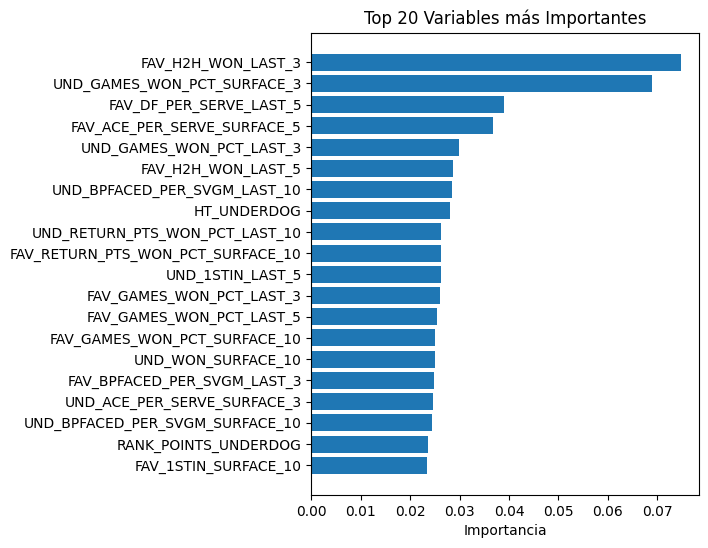

In [26]:
import matplotlib.pyplot as plt
dic = {}
for i in range(0,len(golden_cols)):
    dic[golden_tentative_cols[i]] = final_model.feature_importances_[i]
sorted_importances = sorted(dic.items(), key=lambda item:item[1], reverse=True)
features, scores = zip(*sorted_importances[:20]) # Top 20

plt.figure(figsize=(5, 6))
plt.barh(features, scores)
plt.gca().invert_yaxis()
plt.title('Top 20 Variables más Importantes')
plt.xlabel('Importancia')
plt.show()

## Simulación de apuestas

In [27]:
sim_years = [2023, 2024, 2025, 2026]

Calculamos el Vig de Bet365 y Pinnacle

In [28]:
sim_df = df[df['YEAR'].isin(sim_years)].copy()
sim_df['PREDICTION'] = final_model.predict(sim_df[golden_cols])
sim_df['PROB_UPSET'] = final_model.predict_proba(sim_df[golden_cols])[:, 1]

sim_df['B365_FAVOURITE'] = pd.to_numeric(sim_df['B365_FAVOURITE'], errors='coerce')
sim_df['B365_UNDERDOG'] = pd.to_numeric(sim_df['B365_UNDERDOG'], errors='coerce')
sim_df = sim_df[(sim_df['B365_FAVOURITE'] > 0) & (sim_df['B365_UNDERDOG'] > 0)]

sim_df['PS_FAVOURITE'] = pd.to_numeric(sim_df['PS_FAVOURITE'], errors='coerce')
sim_df['PS_UNDERDOG'] = pd.to_numeric(sim_df['PS_UNDERDOG'], errors='coerce')
sim_df = sim_df[(sim_df['PS_FAVOURITE'] > 0) & (sim_df['PS_UNDERDOG'] > 0)]

# 1. Calculamos la suma de las probabilidades implícitas para Bet365
sim_df['IMPLIED_PROB_B365'] = (1 / sim_df['B365_FAVOURITE']) + (1 / sim_df['B365_UNDERDOG'])

# 2. Calculamos el Vig de Bet365
sim_df['VIG_B365'] = (sim_df['IMPLIED_PROB_B365'] - 1.0) * 100

# 3. Repetimos para Pinnacle
sim_df['IMPLIED_PROB_PS'] = (1 / sim_df['PS_FAVOURITE']) + (1 / sim_df['PS_UNDERDOG'])
sim_df['VIG_PS'] = (sim_df['IMPLIED_PROB_PS'] - 1.0) * 100

# 4. Calculamos la media de todo el dataset
mean_vig_b365 = sim_df['VIG_B365'].mean()
mean_vig_ps = sim_df['VIG_PS'].mean()

print("--- VIG (2023-2026) ---")
print(f"Vig Medio Bet365: {mean_vig_b365:.2f}%")
print(f"Vig Medio Pinnacle: {mean_vig_ps:.2f}%")

--- VIG (2023-2026) ---
Vig Medio Bet365: 5.20%
Vig Medio Pinnacle: 2.63%


In [29]:
sim_df.shape

(7277, 440)

### Estrategia 1: Apostar a todos los partidos

#### Modelo sin pesos

In [30]:
sim_df = df[df['YEAR'].isin(sim_years)].copy()
sim_df['PREDICTION'] = final_model.predict(sim_df[golden_cols])
sim_df['PROB_UPSET'] = final_model.predict_proba(sim_df[golden_cols])[:, 1]

sim_df['B365_FAVOURITE'] = pd.to_numeric(sim_df['B365_FAVOURITE'], errors='coerce')
sim_df['B365_UNDERDOG'] = pd.to_numeric(sim_df['B365_UNDERDOG'], errors='coerce')
sim_df = sim_df[(sim_df['B365_FAVOURITE'] > 0) & (sim_df['B365_UNDERDOG'] > 0)]

sim_df['PS_FAVOURITE'] = pd.to_numeric(sim_df['PS_FAVOURITE'], errors='coerce')
sim_df['PS_UNDERDOG'] = pd.to_numeric(sim_df['PS_UNDERDOG'], errors='coerce')
sim_df = sim_df[(sim_df['PS_FAVOURITE'] > 0) & (sim_df['PS_UNDERDOG'] > 0)]

def basic_bet_B365(row):
    if pd.isna(row['B365_UNDERDOG']) or pd.isna(row['B365_FAVOURITE']):
        return 0.0, 0 
    
    # Apostamos al underdog
    if row['PREDICTION'] == 1:
        if row['UPSET'] == 1:
            # Devuelve una tupla (beneficio, contador apuestas)
            return row['B365_UNDERDOG'] - 1.0, 1
        else:
            return -1.0, 1
            
    # 3. Apostamos al favorito
    elif row['PREDICTION'] == 0:
        if row['UPSET'] == 0:
            return row['B365_FAVOURITE'] - 1.0, 1
        else:
            return -1.0, 1


def basic_bet_PS(row):
    if pd.isna(row['PS_UNDERDOG']) or pd.isna(row['PS_FAVOURITE']):
        return 0.0, 0 
    
    # Apostamos al underdog
    if row['PREDICTION'] == 1:
        if row['UPSET'] == 1:
            # Devuelve una tupla (beneficio, contador apuestas)
            return row['PS_UNDERDOG'] - 1.0, 1
        else:
            return -1.0, 1
            
    # 3. Apostamos al favorito
    elif row['PREDICTION'] == 0:
        if row['UPSET'] == 0:
            return row['PS_FAVOURITE'] - 1.0, 1
        else:
            return -1.0, 1

sim_df[['PROFIT_B365', 'BET_B365']] = sim_df.apply(lambda row: pd.Series(basic_bet_B365(row)), axis=1)
sim_df[['PROFIT_PS', 'BET_PS']] = sim_df.apply(lambda row: pd.Series(basic_bet_PS(row)), axis=1)

total_bets_B365 = sim_df['BET_B365'].sum()
total_profit_B365 = sim_df['PROFIT_B365'].sum()
yield_B365 = (total_profit_B365 / total_bets_B365) * 100 if total_bets_B365 > 0 else 0.0

total_bets_PS = sim_df['BET_PS'].sum()
total_profit_PS = sim_df['PROFIT_PS'].sum()
yield_PS = (total_profit_PS / total_bets_PS) * 100 if total_bets_PS > 0 else 0.0

print("--- ESTRATEGIA: APOSTAR A TODOS LOS PARTIDOS (BET365) ---")
print(f"Apuestas realizadas: {int(total_bets_B365)}")
print(f"Beneficio: {total_profit_B365:.2f} unidades")
print(f"Yield (Retorno sobre inversión): {yield_B365:.2f}%\n")

print("--- ESTRATEGIA: APOSTAR A TODOS LOS PARTIDOS (PINNACLE) ---")
print(f"Apuestas realizadas: {int(total_bets_PS)}")
print(f"Beneficio: {total_profit_PS:.2f} unidades")
print(f"Yield (Retorno sobre inversión): {yield_PS:.2f}%\n")

--- ESTRATEGIA: APOSTAR A TODOS LOS PARTIDOS (BET365) ---
Apuestas realizadas: 7277
Beneficio: -266.65 unidades
Yield (Retorno sobre inversión): -3.66%

--- ESTRATEGIA: APOSTAR A TODOS LOS PARTIDOS (PINNACLE) ---
Apuestas realizadas: 7277
Beneficio: -102.33 unidades
Yield (Retorno sobre inversión): -1.41%



| Modelo | Gestión de Riesgo | Partidos Apostados | Apuestas BET365 | Beneficio BET365 | Yield BET365 | Apuestas Pinnacle | Beneficio Pinnacle | Yield Pinnacle |
|-|-|-|-|-|-|-|-|-|
| Sin Pesos | Flat Betting | Todos | 7277 | -266.65 u | -3.66% | 7277 | -102.33 u | -1.41% |

#### Modelo con pesos y calibrador

In [31]:
sim_df = df[df['YEAR'].isin(sim_years)].copy()
sim_df['PREDICTION'] = final_model_weighted.predict(sim_df[golden_cols])
sim_df['PROB_UPSET'] = final_model_weighted.predict_proba(sim_df[golden_cols])[:, 1]

sim_df['B365_FAVOURITE'] = pd.to_numeric(sim_df['B365_FAVOURITE'], errors='coerce')
sim_df['B365_UNDERDOG'] = pd.to_numeric(sim_df['B365_UNDERDOG'], errors='coerce')
sim_df = sim_df[(sim_df['B365_FAVOURITE'] > 0) & (sim_df['B365_UNDERDOG'] > 0)]

sim_df['PS_FAVOURITE'] = pd.to_numeric(sim_df['PS_FAVOURITE'], errors='coerce')
sim_df['PS_UNDERDOG'] = pd.to_numeric(sim_df['PS_UNDERDOG'], errors='coerce')
sim_df = sim_df[(sim_df['PS_FAVOURITE'] > 0) & (sim_df['PS_UNDERDOG'] > 0)]

def basic_bet_B365(row):
    if pd.isna(row['B365_UNDERDOG']) or pd.isna(row['B365_FAVOURITE']):
        return 0.0, 0 
    
    # Apostamos al underdog
    if row['PREDICTION'] == 1:
        if row['UPSET'] == 1:
            # Devuelve una tupla (beneficio, contador apuestas)
            return row['B365_UNDERDOG'] - 1.0, 1
        else:
            return -1.0, 1
            
    # 3. Apostamos al favorito
    elif row['PREDICTION'] == 0:
        if row['UPSET'] == 0:
            return row['B365_FAVOURITE'] - 1.0, 1
        else:
            return -1.0, 1


def basic_bet_PS(row):
    if pd.isna(row['PS_UNDERDOG']) or pd.isna(row['PS_FAVOURITE']):
        return 0.0, 0 
    
    # Apostamos al underdog
    if row['PREDICTION'] == 1:
        if row['UPSET'] == 1:
            # Devuelve una tupla (beneficio, contador apuestas)
            return row['PS_UNDERDOG'] - 1.0, 1
        else:
            return -1.0, 1
            
    # 3. Apostamos al favorito
    elif row['PREDICTION'] == 0:
        if row['UPSET'] == 0:
            return row['PS_FAVOURITE'] - 1.0, 1
        else:
            return -1.0, 1

sim_df[['PROFIT_B365', 'BET_B365']] = sim_df.apply(lambda row: pd.Series(basic_bet_B365(row)), axis=1)
sim_df[['PROFIT_PS', 'BET_PS']] = sim_df.apply(lambda row: pd.Series(basic_bet_PS(row)), axis=1)

total_bets_B365 = sim_df['BET_B365'].sum()
total_profit_B365 = sim_df['PROFIT_B365'].sum()
yield_B365 = (total_profit_B365 / total_bets_B365) * 100 if total_bets_B365 > 0 else 0.0

total_bets_PS = sim_df['BET_PS'].sum()
total_profit_PS = sim_df['PROFIT_PS'].sum()
yield_PS = (total_profit_PS / total_bets_PS) * 100 if total_bets_PS > 0 else 0.0

print("--- ESTRATEGIA: APOSTAR A TODOS LOS PARTIDOS (BET365) ---")
print(f"Apuestas realizadas: {int(total_bets_B365)}")
print(f"Beneficio: {total_profit_B365:.2f} unidades")
print(f"Yield (Retorno sobre inversión): {yield_B365:.2f}%\n")

print("--- ESTRATEGIA: APOSTAR A TODOS LOS PARTIDOS (PINNACLE) ---")
print(f"Apuestas realizadas: {int(total_bets_PS)}")
print(f"Beneficio: {total_profit_PS:.2f} unidades")
print(f"Yield (Retorno sobre inversión): {yield_PS:.2f}%\n")

--- ESTRATEGIA: APOSTAR A TODOS LOS PARTIDOS (BET365) ---
Apuestas realizadas: 7277
Beneficio: -258.42 unidades
Yield (Retorno sobre inversión): -3.55%

--- ESTRATEGIA: APOSTAR A TODOS LOS PARTIDOS (PINNACLE) ---
Apuestas realizadas: 7277
Beneficio: -92.41 unidades
Yield (Retorno sobre inversión): -1.27%



| Modelo | Gestión de Riesgo | Partidos Apostados | Apuestas BET365 | Beneficio BET365 | Yield BET365 | Apuestas Pinnacle | Beneficio Pinnacle | Yield Pinnacle |
|-|-|-|-|-|-|-|-|-|
| Sin Pesos | Flat Betting | Todos | 7277 | -266.65 u | -3.66% | 7277 | -102.33 u | -1.41% |
| Con Pesos | Flat Betting | Todos | 7277 | -258.42 u | -3.55% | 7277 | -92.41 u | -1.27% |

### Estrategia 2: Apostar Edge > 5%

#### Modelo sin pesos

In [32]:
sim_df = df[df['YEAR'].isin(sim_years)].copy()
sim_df['PREDICTION'] = final_model.predict(sim_df[golden_cols])
sim_df['PROB_UPSET'] = final_model.predict_proba(sim_df[golden_cols])[:, 1]
sim_df['PROB_FAV'] = 1.0 - sim_df['PROB_UPSET']

sim_df['B365_FAVOURITE'] = pd.to_numeric(sim_df['B365_FAVOURITE'], errors='coerce')
sim_df['B365_UNDERDOG'] = pd.to_numeric(sim_df['B365_UNDERDOG'], errors='coerce')
sim_df = sim_df[(sim_df['B365_FAVOURITE'] > 0) & (sim_df['B365_UNDERDOG'] > 0)]

sim_df['PS_FAVOURITE'] = pd.to_numeric(sim_df['PS_FAVOURITE'], errors='coerce')
sim_df['PS_UNDERDOG'] = pd.to_numeric(sim_df['PS_UNDERDOG'], errors='coerce')
sim_df = sim_df[(sim_df['PS_FAVOURITE'] > 0) & (sim_df['PS_UNDERDOG'] > 0)]

MIN_VALUE_EDGE = 0.05

def edge_bet_B365(row):
    if pd.isna(row['B365_UNDERDOG']) or pd.isna(row['B365_FAVOURITE']):
        return 0.0, 0

    edge_underdog = (row['PROB_UPSET'] * row['B365_UNDERDOG']) - 1.0
    edge_fav = (row['PROB_FAV'] * row['B365_FAVOURITE']) - 1.0
    
    # Apostamos al underdog
    if edge_underdog > MIN_VALUE_EDGE and edge_underdog >= edge_fav:
        if row['UPSET'] == 1:
            return row['B365_UNDERDOG'] - 1.0, 1
        else:
            return -1.0, 1
            
    # Apostamos al favorito
    elif edge_fav > MIN_VALUE_EDGE:
        if row['UPSET'] == 0:
            return row['B365_FAVOURITE'] - 1.0, 1
        else:
            return -1.0, 1

    # No hay edge en ninguno
    return 0.0, 0


def edge_bet_PS(row):
    if pd.isna(row['PS_UNDERDOG']) or pd.isna(row['PS_FAVOURITE']):
        return 0.0, 0

    edge_underdog = (row['PROB_UPSET'] * row['PS_UNDERDOG']) - 1.0
    edge_fav = (row['PROB_FAV'] * row['PS_FAVOURITE']) - 1.0
    
    # Apostamos al underdog
    if edge_underdog > MIN_VALUE_EDGE and edge_underdog >= edge_fav:
        if row['UPSET'] == 1:
            return row['PS_UNDERDOG'] - 1.0, 1
        else:
            return -1.0, 1
            
    # Apostamos al favorito
    elif edge_fav > MIN_VALUE_EDGE:
        if row['UPSET'] == 0:
            return row['PS_FAVOURITE'] - 1.0, 1
        else:
            return -1.0, 1

    # No hay edge en ninguno
    return 0.0, 0

sim_df[['PROFIT_B365', 'BET_B365']] = sim_df.apply(lambda row: pd.Series(edge_bet_B365(row)), axis=1)
sim_df[['PROFIT_PS', 'BET_PS']] = sim_df.apply(lambda row: pd.Series(edge_bet_PS(row)), axis=1)

total_bets_B365 = sim_df['BET_B365'].sum()
total_profit_B365 = sim_df['PROFIT_B365'].sum()
yield_B365 = (total_profit_B365 / total_bets_B365) * 100 if total_bets_B365 > 0 else 0.0

total_bets_PS = sim_df['BET_PS'].sum()
total_profit_PS = sim_df['PROFIT_PS'].sum()
yield_PS = (total_profit_PS / total_bets_PS) * 100 if total_bets_PS > 0 else 0.0

print(f"--- ESTRATEGIA: APOSTAR A TODOS LOS PARTIDOS CON EDGE > {MIN_VALUE_EDGE*100}% (BET365) ---")
print(f"Apuestas realizadas: {int(total_bets_B365)}")
print(f"Beneficio: {total_profit_B365:.2f} unidades")
print(f"Yield (Retorno sobre inversión): {yield_B365:.2f}%\n")

print(f"--- ESTRATEGIA: APOSTAR A TODOS LOS PARTIDOS CON EDGE > {MIN_VALUE_EDGE*100}% (PINNACLE) ---")
print(f"Apuestas realizadas: {int(total_bets_PS)}")
print(f"Beneficio: {total_profit_PS:.2f} unidades")
print(f"Yield (Retorno sobre inversión): {yield_PS:.2f}%\n")

--- ESTRATEGIA: APOSTAR A TODOS LOS PARTIDOS CON EDGE > 5.0% (BET365) ---
Apuestas realizadas: 4685
Beneficio: -521.08 unidades
Yield (Retorno sobre inversión): -11.12%

--- ESTRATEGIA: APOSTAR A TODOS LOS PARTIDOS CON EDGE > 5.0% (PINNACLE) ---
Apuestas realizadas: 5337
Beneficio: -348.97 unidades
Yield (Retorno sobre inversión): -6.54%



| Modelo | Gestión de Riesgo | Partidos Apostados | Apuestas BET365 | Beneficio BET365 | Yield BET365 | Apuestas Pinnacle | Beneficio Pinnacle | Yield Pinnacle |
|-|-|-|-|-|-|-|-|-|
| Sin Pesos | Flat Betting | Todos | 7277 | -266.65 u | -3.66% | 7277 | -102.33 u | -1.41% |
| Con Pesos | Flat Betting | Todos | 7277 | -258.42 u | -3.55% | 7277 | -92.41 u | -1.27% |
| Sin Pesos | Flat Betting | Edge > 0.05 | 4685 | -521.08 u | -11.12% | 5337 | -348.97 u | -6.54% |

#### Modelo con pesos y calibrador

In [33]:
sim_df = df[df['YEAR'].isin(sim_years)].copy()
sim_df['PREDICTION'] = final_model_weighted.predict(sim_df[golden_cols])
sim_df['PROB_UPSET'] = final_model_weighted.predict_proba(sim_df[golden_cols])[:, 1]
sim_df['PROB_FAV'] = 1.0 - sim_df['PROB_UPSET']

sim_df['B365_FAVOURITE'] = pd.to_numeric(sim_df['B365_FAVOURITE'], errors='coerce')
sim_df['B365_UNDERDOG'] = pd.to_numeric(sim_df['B365_UNDERDOG'], errors='coerce')
sim_df = sim_df[(sim_df['B365_FAVOURITE'] > 0) & (sim_df['B365_UNDERDOG'] > 0)]

sim_df['PS_FAVOURITE'] = pd.to_numeric(sim_df['PS_FAVOURITE'], errors='coerce')
sim_df['PS_UNDERDOG'] = pd.to_numeric(sim_df['PS_UNDERDOG'], errors='coerce')
sim_df = sim_df[(sim_df['PS_FAVOURITE'] > 0) & (sim_df['PS_UNDERDOG'] > 0)]

MIN_VALUE_EDGE = 0.05

def edge_bet_B365(row):
    if pd.isna(row['B365_UNDERDOG']) or pd.isna(row['B365_FAVOURITE']):
        return 0.0, 0

    edge_underdog = (row['PROB_UPSET'] * row['B365_UNDERDOG']) - 1.0
    edge_fav = (row['PROB_FAV'] * row['B365_FAVOURITE']) - 1.0
    
    # Apostamos al underdog
    if edge_underdog > MIN_VALUE_EDGE and edge_underdog >= edge_fav:
        if row['UPSET'] == 1:
            return row['B365_UNDERDOG'] - 1.0, 1
        else:
            return -1.0, 1
            
    # Apostamos al favorito
    elif edge_fav > MIN_VALUE_EDGE:
        if row['UPSET'] == 0:
            return row['B365_FAVOURITE'] - 1.0, 1
        else:
            return -1.0, 1

    # No hay edge en ninguno
    return 0.0, 0


def edge_bet_PS(row):
    if pd.isna(row['PS_UNDERDOG']) or pd.isna(row['PS_FAVOURITE']):
        return 0.0, 0

    edge_underdog = (row['PROB_UPSET'] * row['PS_UNDERDOG']) - 1.0
    edge_fav = (row['PROB_FAV'] * row['PS_FAVOURITE']) - 1.0
    
    # Apostamos al underdog
    if edge_underdog > MIN_VALUE_EDGE and edge_underdog >= edge_fav:
        if row['UPSET'] == 1:
            return row['PS_UNDERDOG'] - 1.0, 1
        else:
            return -1.0, 1
            
    # Apostamos al favorito
    elif edge_fav > MIN_VALUE_EDGE:
        if row['UPSET'] == 0:
            return row['PS_FAVOURITE'] - 1.0, 1
        else:
            return -1.0, 1

    # No hay edge en ninguno
    return 0.0, 0

sim_df[['PROFIT_B365', 'BET_B365']] = sim_df.apply(lambda row: pd.Series(edge_bet_B365(row)), axis=1)
sim_df[['PROFIT_PS', 'BET_PS']] = sim_df.apply(lambda row: pd.Series(edge_bet_PS(row)), axis=1)

total_bets_B365 = sim_df['BET_B365'].sum()
total_profit_B365 = sim_df['PROFIT_B365'].sum()
yield_B365 = (total_profit_B365 / total_bets_B365) * 100 if total_bets_B365 > 0 else 0.0

total_bets_PS = sim_df['BET_PS'].sum()
total_profit_PS = sim_df['PROFIT_PS'].sum()
yield_PS = (total_profit_PS / total_bets_PS) * 100 if total_bets_PS > 0 else 0.0

print(f"--- ESTRATEGIA: APOSTAR A TODOS LOS PARTIDOS CON EDGE > {MIN_VALUE_EDGE*100}% (BET365) ---")
print(f"Apuestas realizadas: {int(total_bets_B365)}")
print(f"Beneficio: {total_profit_B365:.2f} unidades")
print(f"Yield (Retorno sobre inversión): {yield_B365:.2f}%\n")

print(f"--- ESTRATEGIA: APOSTAR A TODOS LOS PARTIDOS CON EDGE > {MIN_VALUE_EDGE*100}% (PINNACLE) ---")
print(f"Apuestas realizadas: {int(total_bets_PS)}")
print(f"Beneficio: {total_profit_PS:.2f} unidades")
print(f"Yield (Retorno sobre inversión): {yield_PS:.2f}%\n")

--- ESTRATEGIA: APOSTAR A TODOS LOS PARTIDOS CON EDGE > 5.0% (BET365) ---
Apuestas realizadas: 4738
Beneficio: -557.02 unidades
Yield (Retorno sobre inversión): -11.76%

--- ESTRATEGIA: APOSTAR A TODOS LOS PARTIDOS CON EDGE > 5.0% (PINNACLE) ---
Apuestas realizadas: 5324
Beneficio: -370.85 unidades
Yield (Retorno sobre inversión): -6.97%



| Modelo | Gestión de Riesgo | Partidos Apostados | Apuestas BET365 | Beneficio BET365 | Yield BET365 | Apuestas Pinnacle | Beneficio Pinnacle | Yield Pinnacle |
|-|-|-|-|-|-|-|-|-|
| Sin Pesos | Flat Betting | Todos | 7277 | -266.65 u | -3.66% | 7277 | -102.33 u | -1.41% |
| Con Pesos | Flat Betting | Todos | 7277 | -258.42 u | -3.55% | 7277 | -92.41 u | -1.27% |
| Sin Pesos | Flat Betting | Edge > 0.05 | 4685 | -521.08 u | -11.12% | 5337 | -348.97 u | -6.54% |
| Con Pesos | Flat Betting | Edge > 0.05 | 4738 | -557.02 u | -11.76% | 5324 | -370.85 u | -6.97% |

### Estrategia 3: Apostar Prob Upset > 50%

#### Modelo sin pesos

In [34]:
sim_df = df[df['YEAR'].isin(sim_years)].copy()
sim_df['PREDICTION'] = final_model.predict(sim_df[golden_cols])
sim_df['PROB_UPSET'] = final_model.predict_proba(sim_df[golden_cols])[:, 1]

sim_df['B365_FAVOURITE'] = pd.to_numeric(sim_df['B365_FAVOURITE'], errors='coerce')
sim_df['B365_UNDERDOG'] = pd.to_numeric(sim_df['B365_UNDERDOG'], errors='coerce')
sim_df = sim_df[(sim_df['B365_FAVOURITE'] > 0) & (sim_df['B365_UNDERDOG'] > 0)]

sim_df['PS_FAVOURITE'] = pd.to_numeric(sim_df['PS_FAVOURITE'], errors='coerce')
sim_df['PS_UNDERDOG'] = pd.to_numeric(sim_df['PS_UNDERDOG'], errors='coerce')
sim_df = sim_df[(sim_df['PS_FAVOURITE'] > 0) & (sim_df['PS_UNDERDOG'] > 0)]

def upset_bet_B365(row):
    if pd.isna(row['B365_UNDERDOG']):
        return 0.0, 0 
    
    # Apostamos al underdog
    if row['PREDICTION'] == 1:
        if row['UPSET'] == 1:
            # Devuelve una tupla (beneficio, contador apuestas)
            return row['B365_UNDERDOG'] - 1.0, 1
        else:
            return -1.0, 1

    # No apostamos
    return 0.0, 0


def upset_bet_PS(row):
    if pd.isna(row['PS_UNDERDOG']):
        return 0.0, 0
    
    # Apostamos al underdog
    if row['PREDICTION'] == 1:
        if row['UPSET'] == 1:
            # Devuelve una tupla (beneficio, contador apuestas)
            return row['PS_UNDERDOG'] - 1.0, 1
        else:
            return -1.0, 1
            
    # No apostamos
    return 0.0, 0

sim_df[['PROFIT_B365', 'BET_B365']] = sim_df.apply(lambda row: pd.Series(upset_bet_B365(row)), axis=1)
sim_df[['PROFIT_PS', 'BET_PS']] = sim_df.apply(lambda row: pd.Series(upset_bet_PS(row)), axis=1)

total_bets_B365 = sim_df['BET_B365'].sum()
total_profit_B365 = sim_df['PROFIT_B365'].sum()
yield_B365 = (total_profit_B365 / total_bets_B365) * 100 if total_bets_B365 > 0 else 0.0

total_bets_PS = sim_df['BET_PS'].sum()
total_profit_PS = sim_df['PROFIT_PS'].sum()
yield_PS = (total_profit_PS / total_bets_PS) * 100 if total_bets_PS > 0 else 0.0

print("--- ESTRATEGIA: APOSTAR A LOS PARTIDOS QUE PREDECIMOS UPSET (BET365) ---")
print(f"Apuestas realizadas: {int(total_bets_B365)}")
print(f"Beneficio: {total_profit_B365:.2f} unidades")
print(f"Yield (Retorno sobre inversión): {yield_B365:.2f}%\n")

print("--- ESTRATEGIA: APOSTAR A LOS PARTIDOS QUE PREDECIMOS UPSET (PINNACLE) ---")
print(f"Apuestas realizadas: {int(total_bets_PS)}")
print(f"Beneficio: {total_profit_PS:.2f} unidades")
print(f"Yield (Retorno sobre inversión): {yield_PS:.2f}%\n")

--- ESTRATEGIA: APOSTAR A LOS PARTIDOS QUE PREDECIMOS UPSET (BET365) ---
Apuestas realizadas: 931
Beneficio: -7.10 unidades
Yield (Retorno sobre inversión): -0.76%

--- ESTRATEGIA: APOSTAR A LOS PARTIDOS QUE PREDECIMOS UPSET (PINNACLE) ---
Apuestas realizadas: 931
Beneficio: 15.87 unidades
Yield (Retorno sobre inversión): 1.70%



| Modelo | Gestión de Riesgo | Partidos Apostados | Apuestas BET365 | Beneficio BET365 | Yield BET365 | Apuestas Pinnacle | Beneficio Pinnacle | Yield Pinnacle |
|-|-|-|-|-|-|-|-|-|
| Sin Pesos | Flat Betting | Todos | 7277 | -266.65 u | -3.66% | 7277 | -102.33 u | -1.41% |
| Con Pesos | Flat Betting | Todos | 7277 | -258.42 u | -3.55% | 7277 | -92.41 u | -1.27% |
| Sin Pesos | Flat Betting | Edge > 0.05 | 4685 | -521.08 u | -11.12% | 5337 | -348.97 u | -6.54% |
| Con Pesos | Flat Betting | Edge > 0.05 | 4738 | -557.02 u | -11.76% | 5324 | -370.85 u | -6.97% |
| Sin Pesos | Flat Betting | Prob Upset > 0.5 | 931 | -7.10 u | -0.76% | 931 | 15.87 u | 1.70% |

#### Modelo con pesos y calibrador

In [35]:
sim_df = df[df['YEAR'].isin(sim_years)].copy()
sim_df['PREDICTION'] = final_model_weighted.predict(sim_df[golden_cols])
sim_df['PROB_UPSET'] = final_model_weighted.predict_proba(sim_df[golden_cols])[:, 1]

sim_df['B365_FAVOURITE'] = pd.to_numeric(sim_df['B365_FAVOURITE'], errors='coerce')
sim_df['B365_UNDERDOG'] = pd.to_numeric(sim_df['B365_UNDERDOG'], errors='coerce')
sim_df = sim_df[(sim_df['B365_FAVOURITE'] > 0) & (sim_df['B365_UNDERDOG'] > 0)]

sim_df['PS_FAVOURITE'] = pd.to_numeric(sim_df['PS_FAVOURITE'], errors='coerce')
sim_df['PS_UNDERDOG'] = pd.to_numeric(sim_df['PS_UNDERDOG'], errors='coerce')
sim_df = sim_df[(sim_df['PS_FAVOURITE'] > 0) & (sim_df['PS_UNDERDOG'] > 0)]

def upset_bet_B365(row):
    if pd.isna(row['B365_UNDERDOG']):
        return 0.0, 0 
    
    # Apostamos al underdog
    if row['PREDICTION'] == 1:
        if row['UPSET'] == 1:
            # Devuelve una tupla (beneficio, contador apuestas)
            return row['B365_UNDERDOG'] - 1.0, 1
        else:
            return -1.0, 1

    # No apostamos
    return 0.0, 0


def upset_bet_PS(row):
    if pd.isna(row['PS_UNDERDOG']):
        return 0.0, 0
    
    # Apostamos al underdog
    if row['PREDICTION'] == 1:
        if row['UPSET'] == 1:
            # Devuelve una tupla (beneficio, contador apuestas)
            return row['PS_UNDERDOG'] - 1.0, 1
        else:
            return -1.0, 1
            
    # No apostamos
    return 0.0, 0

sim_df[['PROFIT_B365', 'BET_B365']] = sim_df.apply(lambda row: pd.Series(upset_bet_B365(row)), axis=1)
sim_df[['PROFIT_PS', 'BET_PS']] = sim_df.apply(lambda row: pd.Series(upset_bet_PS(row)), axis=1)

total_bets_B365 = sim_df['BET_B365'].sum()
total_profit_B365 = sim_df['PROFIT_B365'].sum()
yield_B365 = (total_profit_B365 / total_bets_B365) * 100 if total_bets_B365 > 0 else 0.0

total_bets_PS = sim_df['BET_PS'].sum()
total_profit_PS = sim_df['PROFIT_PS'].sum()
yield_PS = (total_profit_PS / total_bets_PS) * 100 if total_bets_PS > 0 else 0.0

print("--- ESTRATEGIA: APOSTAR A LOS PARTIDOS QUE PREDECIMOS UPSET (BET365) ---")
print(f"Apuestas realizadas: {int(total_bets_B365)}")
print(f"Beneficio: {total_profit_B365:.2f} unidades")
print(f"Yield (Retorno sobre inversión): {yield_B365:.2f}%\n")

print("--- ESTRATEGIA: APOSTAR A LOS PARTIDOS QUE PREDECIMOS UPSET (PINNACLE) ---")
print(f"Apuestas realizadas: {int(total_bets_PS)}")
print(f"Beneficio: {total_profit_PS:.2f} unidades")
print(f"Yield (Retorno sobre inversión): {yield_PS:.2f}%\n")

--- ESTRATEGIA: APOSTAR A LOS PARTIDOS QUE PREDECIMOS UPSET (BET365) ---
Apuestas realizadas: 1351
Beneficio: -19.72 unidades
Yield (Retorno sobre inversión): -1.46%

--- ESTRATEGIA: APOSTAR A LOS PARTIDOS QUE PREDECIMOS UPSET (PINNACLE) ---
Apuestas realizadas: 1351
Beneficio: 14.10 unidades
Yield (Retorno sobre inversión): 1.04%



| Modelo | Gestión de Riesgo | Partidos Apostados | Apuestas BET365 | Beneficio BET365 | Yield BET365 | Apuestas Pinnacle | Beneficio Pinnacle | Yield Pinnacle |
|-|-|-|-|-|-|-|-|-|
| Sin Pesos | Flat Betting | Todos | 7277 | -266.65 u | -3.66% | 7277 | -102.33 u | -1.41% |
| Con Pesos | Flat Betting | Todos | 7277 | -258.42 u | -3.55% | 7277 | -92.41 u | -1.27% |
| Sin Pesos | Flat Betting | Edge > 0.05 | 4685 | -521.08 u | -11.12% | 5337 | -348.97 u | -6.54% |
| Con Pesos | Flat Betting | Edge > 0.05 | 4738 | -557.02 u | -11.76% | 5324 | -370.85 u | -6.97% |
| Sin Pesos | Flat Betting | Prob Upset > 0.5 | 931 | -7.10 u | -0.76% | 931 | 15.87 u | 1.70% |
| Con Pesos | Flat Betting | Prob Upset > 0.5 | 1351 | -19.72 u | -1.46% | 1351 | 14.10 u | 1.04% |

### Estrategia 4: Apostar Edge > 5% y Prob Upset > 50%

#### Modelo sin pesos

In [36]:
sim_df = df[df['YEAR'].isin(sim_years)].copy()
sim_df['PREDICTION'] = final_model.predict(sim_df[golden_cols])
sim_df['PROB_UPSET'] = final_model.predict_proba(sim_df[golden_cols])[:, 1]

sim_df['B365_FAVOURITE'] = pd.to_numeric(sim_df['B365_FAVOURITE'], errors='coerce')
sim_df['B365_UNDERDOG'] = pd.to_numeric(sim_df['B365_UNDERDOG'], errors='coerce')
sim_df = sim_df[(sim_df['B365_FAVOURITE'] > 0) & (sim_df['B365_UNDERDOG'] > 0)]

sim_df['PS_FAVOURITE'] = pd.to_numeric(sim_df['PS_FAVOURITE'], errors='coerce')
sim_df['PS_UNDERDOG'] = pd.to_numeric(sim_df['PS_UNDERDOG'], errors='coerce')
sim_df = sim_df[(sim_df['PS_FAVOURITE'] > 0) & (sim_df['PS_UNDERDOG'] > 0)]

MIN_VALUE_EDGE = 0.05

def upset_edge_bet_B365(row):
    if pd.isna(row['B365_UNDERDOG']) or pd.isna(row['PROB_UPSET']):
        return 0.0, 0

    edge_upset = (row['PROB_UPSET'] * row['B365_UNDERDOG']) - 1.0
    
    # Apostamos al underdog
    if row['PREDICTION'] and edge_upset > MIN_VALUE_EDGE:
        if row['UPSET']:
            return row['B365_UNDERDOG'] - 1.0, 1
        else:
            return -1.0, 1

    # No apostamos
    return 0.0, 0


def upset_edge_bet_PS(row):
    if pd.isna(row['PS_UNDERDOG']) or pd.isna(row['PROB_UPSET']):
        return 0.0, 0

    edge_upset = (row['PROB_UPSET'] * row['PS_UNDERDOG']) - 1.0
    
    # Apostamos al underdog
    if row['PREDICTION'] and  edge_upset > MIN_VALUE_EDGE:
        if row['UPSET']:
            return row['PS_UNDERDOG'] - 1.0, 1
        else:
            return -1.0, 1

    # No hay edge en ninguno
    return 0.0, 0

sim_df[['PROFIT_B365', 'BET_B365']] = sim_df.apply(lambda row: pd.Series(upset_edge_bet_B365(row)), axis=1)
sim_df[['PROFIT_PS', 'BET_PS']] = sim_df.apply(lambda row: pd.Series(upset_edge_bet_PS(row)), axis=1)

total_bets_B365 = sim_df['BET_B365'].sum()
total_profit_B365 = sim_df['PROFIT_B365'].sum()
yield_B365 = (total_profit_B365 / total_bets_B365) * 100 if total_bets_B365 > 0 else 0.0

total_bets_PS = sim_df['BET_PS'].sum()
total_profit_PS = sim_df['PROFIT_PS'].sum()
yield_PS = (total_profit_PS / total_bets_PS) * 100 if total_bets_PS > 0 else 0.0

print(f"--- ESTRATEGIA: APOSTAR A TODOS LOS PARTIDOS CON EDGE > {MIN_VALUE_EDGE*100}% (BET365) ---")
print(f"Apuestas realizadas: {int(total_bets_B365)}")
print(f"Beneficio: {total_profit_B365:.2f} unidades")
print(f"Yield (Retorno sobre inversión): {yield_B365:.2f}%\n")

print(f"--- ESTRATEGIA: APOSTAR A TODOS LOS PARTIDOS CON EDGE > {MIN_VALUE_EDGE*100}% (PINNACLE) ---")
print(f"Apuestas realizadas: {int(total_bets_PS)}")
print(f"Beneficio: {total_profit_PS:.2f} unidades")
print(f"Yield (Retorno sobre inversión): {yield_PS:.2f}%\n")

--- ESTRATEGIA: APOSTAR A TODOS LOS PARTIDOS CON EDGE > 5.0% (BET365) ---
Apuestas realizadas: 303
Beneficio: 30.98 unidades
Yield (Retorno sobre inversión): 10.22%

--- ESTRATEGIA: APOSTAR A TODOS LOS PARTIDOS CON EDGE > 5.0% (PINNACLE) ---
Apuestas realizadas: 343
Beneficio: 36.52 unidades
Yield (Retorno sobre inversión): 10.65%



| Modelo | Gestión de Riesgo | Partidos Apostados | Apuestas BET365 | Beneficio BET365 | Yield BET365 | Apuestas Pinnacle | Beneficio Pinnacle | Yield Pinnacle |
|-|-|-|-|-|-|-|-|-|
| Sin Pesos | Flat Betting | Todos | 7277 | -266.65 u | -3.66% | 7277 | -102.33 u | -1.41% |
| Con Pesos | Flat Betting | Todos | 7277 | -258.42 u | -3.55% | 7277 | -92.41 u | -1.27% |
| Sin Pesos | Flat Betting | Edge > 0.05 | 4685 | -521.08 u | -11.12% | 5337 | -348.97 u | -6.54% |
| Con Pesos | Flat Betting | Edge > 0.05 | 4738 | -557.02 u | -11.76% | 5324 | -370.85 u | -6.97% |
| Sin Pesos | Flat Betting | Prob Upset > 0.5 | 931 | -7.10 u | -0.76% | 931 | 15.87 u | 1.70% |
| Con Pesos | Flat Betting | Prob Upset > 0.5 | 1351 | -19.72 u | -1.46% | 1351 | 14.10 u | 1.04% |
| Sin Pesos | Flat Betting | Edge>5% y Upset>50% | 303 | 30.98 u | 10.22% | 343 | 36.52 u | 10.65% |

#### Modelo con pesos y calibrador

In [37]:
sim_df = df[df['YEAR'].isin(sim_years)].copy()
sim_df['PREDICTION'] = final_model_weighted.predict(sim_df[golden_cols])
sim_df['PROB_UPSET'] = final_model_weighted.predict_proba(sim_df[golden_cols])[:, 1]

sim_df['B365_FAVOURITE'] = pd.to_numeric(sim_df['B365_FAVOURITE'], errors='coerce')
sim_df['B365_UNDERDOG'] = pd.to_numeric(sim_df['B365_UNDERDOG'], errors='coerce')
sim_df = sim_df[(sim_df['B365_FAVOURITE'] > 0) & (sim_df['B365_UNDERDOG'] > 0)]

sim_df['PS_FAVOURITE'] = pd.to_numeric(sim_df['PS_FAVOURITE'], errors='coerce')
sim_df['PS_UNDERDOG'] = pd.to_numeric(sim_df['PS_UNDERDOG'], errors='coerce')
sim_df = sim_df[(sim_df['PS_FAVOURITE'] > 0) & (sim_df['PS_UNDERDOG'] > 0)]

MIN_VALUE_EDGE = 0.05

def upset_edge_bet_B365(row):
    if pd.isna(row['B365_UNDERDOG']) or pd.isna(row['PROB_UPSET']):
        return 0.0, 0

    edge_upset = (row['PROB_UPSET'] * row['B365_UNDERDOG']) - 1.0
    
    # Apostamos al underdog
    if row['PREDICTION'] and edge_upset > MIN_VALUE_EDGE:
        if row['UPSET']:
            return row['B365_UNDERDOG'] - 1.0, 1
        else:
            return -1.0, 1

    # No apostamos
    return 0.0, 0


def upset_edge_bet_PS(row):
    if pd.isna(row['PS_UNDERDOG']) or pd.isna(row['PROB_UPSET']):
        return 0.0, 0

    edge_upset = (row['PROB_UPSET'] * row['PS_UNDERDOG']) - 1.0
    
    # Apostamos al underdog
    if row['PREDICTION'] and  edge_upset > MIN_VALUE_EDGE:
        if row['UPSET']:
            return row['PS_UNDERDOG'] - 1.0, 1
        else:
            return -1.0, 1

    # No hay edge en ninguno
    return 0.0, 0

sim_df[['PROFIT_B365', 'BET_B365']] = sim_df.apply(lambda row: pd.Series(upset_edge_bet_B365(row)), axis=1)
sim_df[['PROFIT_PS', 'BET_PS']] = sim_df.apply(lambda row: pd.Series(upset_edge_bet_PS(row)), axis=1)

total_bets_B365 = sim_df['BET_B365'].sum()
total_profit_B365 = sim_df['PROFIT_B365'].sum()
yield_B365 = (total_profit_B365 / total_bets_B365) * 100 if total_bets_B365 > 0 else 0.0

total_bets_PS = sim_df['BET_PS'].sum()
total_profit_PS = sim_df['PROFIT_PS'].sum()
yield_PS = (total_profit_PS / total_bets_PS) * 100 if total_bets_PS > 0 else 0.0

print(f"--- ESTRATEGIA: APOSTAR A TODOS LOS PARTIDOS CON EDGE > {MIN_VALUE_EDGE*100}% (BET365) ---")
print(f"Apuestas realizadas: {int(total_bets_B365)}")
print(f"Beneficio: {total_profit_B365:.2f} unidades")
print(f"Yield (Retorno sobre inversión): {yield_B365:.2f}%\n")

print(f"--- ESTRATEGIA: APOSTAR A TODOS LOS PARTIDOS CON EDGE > {MIN_VALUE_EDGE*100}% (PINNACLE) ---")
print(f"Apuestas realizadas: {int(total_bets_PS)}")
print(f"Beneficio: {total_profit_PS:.2f} unidades")
print(f"Yield (Retorno sobre inversión): {yield_PS:.2f}%\n")

--- ESTRATEGIA: APOSTAR A TODOS LOS PARTIDOS CON EDGE > 5.0% (BET365) ---
Apuestas realizadas: 579
Beneficio: 18.67 unidades
Yield (Retorno sobre inversión): 3.22%

--- ESTRATEGIA: APOSTAR A TODOS LOS PARTIDOS CON EDGE > 5.0% (PINNACLE) ---
Apuestas realizadas: 621
Beneficio: 40.55 unidades
Yield (Retorno sobre inversión): 6.53%



| Modelo | Gestión de Riesgo | Partidos Apostados | Apuestas BET365 | Beneficio BET365 | Yield BET365 | Apuestas Pinnacle | Beneficio Pinnacle | Yield Pinnacle |
|-|-|-|-|-|-|-|-|-|
| Sin Pesos | Flat Betting | Todos | 7277 | -266.65 u | -3.66% | 7277 | -102.33 u | -1.41% |
| Con Pesos | Flat Betting | Todos | 7277 | -258.42 u | -3.55% | 7277 | -92.41 u | -1.27% |
| Sin Pesos | Flat Betting | Edge > 0.05 | 4685 | -521.08 u | -11.12% | 5337 | -348.97 u | -6.54% |
| Con Pesos | Flat Betting | Edge > 0.05 | 4738 | -557.02 u | -11.76% | 5324 | -370.85 u | -6.97% |
| Sin Pesos | Flat Betting | Prob Upset > 0.5 | 931 | -7.10 u | -0.76% | 931 | 15.87 u | 1.70% |
| Con Pesos | Flat Betting | Prob Upset > 0.5 | 1351 | -19.72 u | -1.46% | 1351 | 14.10 u | 1.04% |
| Sin Pesos | Flat Betting | Edge>5% y Upset>50% | 303 | 30.98 u | 10.22% | 343 | 36.52 u | 10.65% |
| Con Pesos | Flat Betting | Edge>5% y Upset>50% | 579 | 18.67 u | 3.22% | 621 | 40.55 u | 6.53% |

### Podemos observar que en todas las simulaciones ganamos más dinero con las cuotas de Pinnacle, por lo que usaremos éstas para la simulación final

### Simulación de apuestas con stake (diferentes cantidades en función de la confianza de la predicción)

#### Modelo sin pesos

In [38]:
sim_df = df[df['YEAR'].isin(sim_years)].copy()
sim_df['PREDICTION'] = final_model.predict(sim_df[golden_cols])
sim_df['PROB_UPSET'] = final_model.predict_proba(sim_df[golden_cols])[:, 1]

sim_df['PS_FAVOURITE'] = pd.to_numeric(sim_df['PS_FAVOURITE'], errors='coerce')
sim_df['PS_UNDERDOG'] = pd.to_numeric(sim_df['PS_UNDERDOG'], errors='coerce')
sim_df = sim_df[(sim_df['PS_FAVOURITE'] > 0) & (sim_df['PS_UNDERDOG'] > 0)]

# --- PARÁMETROS FINANCIEROS ---
MIN_VALUE_EDGE = 0.05
KELLY_FRACTION = 0.25 # Cuarto de Kelly
BASE_BANKROLL = 1000 # 1000 unidades base
MAX_STAKE_PCT = 0.05 # Nunca apostar más de 50 unidades en un solo partido

def kelly_bet_PS(row):
    if pd.isna(row['PS_UNDERDOG']) or pd.isna(row['PROB_UPSET']):
        return 0.0, 0.0, 0 
        
    prob_upset = row['PROB_UPSET']
    odds = row['PS_UNDERDOG']
    edge_upset = (prob_upset * odds) - 1.0
    
    # Apostar solo si hay edge positivo y se predice un upset
    if row['PREDICTION'] and edge_upset > MIN_VALUE_EDGE:
        
        # Aplicamos fórmula de Kelly
        b = odds - 1.0 # Beneficio neto por unidad apostada
        f_star = edge_upset / b # Porcentaje óptimo de Kelly puro
        
        # Ajustamos a Fraction Kelly y lo pasamos a "Unidades"
        stake = f_star * KELLY_FRACTION * BASE_BANKROLL
        
        # Límite de seguridad
        max_stake_units = BASE_BANKROLL * MAX_STAKE_PCT
        stake = min(stake, max_stake_units)
        
        # Resolvemos la apuesta usando el STAKE
        if row['UPSET'] == 1:
            profit = stake * b # Ganamos el Stake multiplicado por el beneficio neto
            return profit, stake, 1
        else:
            return -stake, stake, 1 # Perdemos todo el Stake
            
    return 0.0, 0.0, 0 # No se apostó

# Aplicamos
sim_df[['PROFIT_KELLY', 'STAKE_KELLY', 'BET_COUNT']] = sim_df.apply(lambda row: pd.Series(kelly_bet_PS(row)), axis=1)

# Cálculos Finales
total_bets = sim_df['BET_COUNT'].sum()
total_staked = sim_df['STAKE_KELLY'].sum()
total_profit = sim_df['PROFIT_KELLY'].sum()
yield_kelly = (total_profit / total_staked) * 100 if total_staked > 0 else 0.0

print("--- ESTRATEGIA KELLY ESTÁTICO: (PINNACLE) ---")
print(f"Apuestas realizadas: {int(total_bets)}")
print(f"Volumen Arriesgado (Total Staked): {total_staked:.2f} unidades")
print(f"Stake Medio por apuesta: {total_staked / total_bets:.2f} unidades" if total_bets > 0 else "0.0")
print(f"Beneficio Neto: {total_profit:.2f} unidades limpias")
print(f"Yield (Retorno sobre inversión): {yield_kelly:.2f}%\n")

--- ESTRATEGIA KELLY ESTÁTICO: (PINNACLE) ---
Apuestas realizadas: 343
Volumen Arriesgado (Total Staked): 13068.49 unidades
Stake Medio por apuesta: 38.10 unidades
Beneficio Neto: 1851.40 unidades limpias
Yield (Retorno sobre inversión): 14.17%



| Modelo | Gestión de Riesgo | Partidos Apostados | Apuestas BET365 | Beneficio BET365 | Yield BET365 | Apuestas Pinnacle | Beneficio Pinnacle | Yield Pinnacle |
|-|-|-|-|-|-|-|-|-|
| Sin Pesos | Flat Betting | Todos | 7277 | -266.65 u | -3.66% | 7277 | -102.33 u | -1.41% |
| Con Pesos | Flat Betting | Todos | 7277 | -258.42 u | -3.55% | 7277 | -92.41 u | -1.27% |
| Sin Pesos | Flat Betting | Edge > 0.05 | 4685 | -521.08 u | -11.12% | 5337 | -348.97 u | -6.54% |
| Con Pesos | Flat Betting | Edge > 0.05 | 4738 | -557.02 u | -11.76% | 5324 | -370.85 u | -6.97% |
| Sin Pesos | Flat Betting | Prob Upset > 0.5 | 931 | -7.10 u | -0.76% | 931 | 15.87 u | 1.70% |
| Con Pesos | Flat Betting | Prob Upset > 0.5 | 1351 | -19.72 u | -1.46% | 1351 | 14.10 u | 1.04% |
| Sin Pesos | Flat Betting | Edge>5% y Upset>50% | 303 | 30.98 u | 10.22% | 343 | 36.52 u | 10.65% |
| Con Pesos | Flat Betting | Edge>5% y Upset>50% | 579 | 18.67 u | 3.22% | 621 | 40.55 u | 6.53% |
| Sin Pesos | Kelly No Dinámico | Edge>5% y Upset>50% | - | - | - | 343 | 1851.40 u | 14.17% |

#### Modelo con pesos y calibrador

In [ ]:
sim_df = df[df['YEAR'].isin(sim_years)].copy()
sim_df['PREDICTION'] = final_model_weighted.predict(sim_df[golden_cols])
sim_df['PROB_UPSET'] = final_model_weighted.predict_proba(sim_df[golden_cols])[:, 1]

sim_df['PS_FAVOURITE'] = pd.to_numeric(sim_df['PS_FAVOURITE'], errors='coerce')
sim_df['PS_UNDERDOG'] = pd.to_numeric(sim_df['PS_UNDERDOG'], errors='coerce')
sim_df = sim_df[(sim_df['PS_FAVOURITE'] > 0) & (sim_df['PS_UNDERDOG'] > 0)]

# --- PARÁMETROS FINANCIEROS ---
MIN_VALUE_EDGE = 0.05
KELLY_FRACTION = 0.25 # Cuarto de Kelly (Conservador y profesional)
BASE_BANKROLL = 1000 # 1000 unidades base
MAX_STAKE_PCT = 0.05 # Nunca apostar más de 50 unidades en un solo partido

def kelly_bet_PS(row):
    if pd.isna(row['PS_UNDERDOG']) or pd.isna(row['PROB_UPSET']):
        return 0.0, 0.0, 0 
        
    prob_upset = row['PROB_UPSET']
    odds = row['PS_UNDERDOG']
    edge_upset = (prob_upset * odds) - 1.0
    
    # Apostar solo si hay edge positivo y se predice un upset
    if row['PREDICTION'] and edge_upset > MIN_VALUE_EDGE:
        
        # Aplicamos fórmula de Kelly
        b = odds - 1.0 # Beneficio neto por unidad apostada
        f_star = edge_upset / b # Porcentaje óptimo de Kelly puro
        
        # Ajustamos a Fraction Kelly y lo pasamos a "Unidades"
        stake = f_star * KELLY_FRACTION * BASE_BANKROLL
        
        # Límite de seguridad
        max_stake_units = BASE_BANKROLL * MAX_STAKE_PCT # El 5% de 1000 = 50 unidades
        stake = min(stake, max_stake_units)
        
        # Resolvemos la apuesta usando el STAKE
        if row['UPSET'] == 1:
            profit = stake * b # Ganamos el Stake multiplicado por el beneficio neto
            return profit, stake, 1
        else:
            return -stake, stake, 1 # Perdemos todo el Stake
            
    return 0.0, 0.0, 0 # No se apostó

# Aplicamos
sim_df[['PROFIT_KELLY', 'STAKE_KELLY', 'BET_COUNT']] = sim_df.apply(lambda row: pd.Series(kelly_bet_PS(row)), axis=1)

# Cálculos Finales
total_bets = sim_df['BET_COUNT'].sum()
total_staked = sim_df['STAKE_KELLY'].sum()
total_profit = sim_df['PROFIT_KELLY'].sum()
yield_kelly = (total_profit / total_staked) * 100 if total_staked > 0 else 0.0

print("--- 🚀 ESTRATEGIA KELLY ESTÁTICO (PINNACLE) ---")
print(f"Apuestas realizadas: {int(total_bets)}")
print(f"Volumen Arriesgado (Total Staked): {total_staked:.2f} unidades")
print(f"Stake Medio por apuesta: {total_staked / total_bets:.2f} unidades" if total_bets > 0 else "0.0")
print(f"Beneficio Neto: {total_profit:.2f} unidades limpias")
print(f"Yield (Retorno sobre inversión): {yield_kelly:.2f}%\n")

--- 🚀 ESTRATEGIA KELLY ESTÁTICO (PINNACLE) ---
Apuestas realizadas: 621
Volumen Arriesgado (Total Staked): 25148.25 unidades
Stake Medio por apuesta: 40.50 unidades
Beneficio Neto: 2140.45 unidades limpias
Yield (Retorno sobre inversión): 8.51%



| Modelo | Gestión de Riesgo | Partidos Apostados | Apuestas BET365 | Beneficio BET365 | Yield BET365 | Apuestas Pinnacle | Beneficio Pinnacle | Yield Pinnacle |
|-|-|-|-|-|-|-|-|-|
| Sin Pesos | Flat Betting | Todos | 7277 | -266.65 u | -3.66% | 7277 | -102.33 u | -1.41% |
| Con Pesos | Flat Betting | Todos | 7277 | -258.42 u | -3.55% | 7277 | -92.41 u | -1.27% |
| Sin Pesos | Flat Betting | Edge > 0.05 | 4685 | -521.08 u | -11.12% | 5337 | -348.97 u | -6.54% |
| Con Pesos | Flat Betting | Edge > 0.05 | 4738 | -557.02 u | -11.76% | 5324 | -370.85 u | -6.97% |
| Sin Pesos | Flat Betting | Prob Upset > 0.5 | 931 | -7.10 u | -0.76% | 931 | 15.87 u | 1.70% |
| Con Pesos | Flat Betting | Prob Upset > 0.5 | 1351 | -19.72 u | -1.46% | 1351 | 14.10 u | 1.04% |
| Sin Pesos | Flat Betting | Edge>5% y Upset>50% | 303 | 30.98 u | 10.22% | 343 | 36.52 u | 10.65% |
| Con Pesos | Flat Betting | Edge>5% y Upset>50% | 579 | 18.67 u | 3.22% | 621 | 40.55 u | 6.53% |
| Sin Pesos | Kelly No Dinámico | Edge>5% y Upset>50% | - | - | - | 343 | 1851.40 u | 14.17% |
| Con Pesos | Kelly No Dinámico | Edge>5% y Upset>50% | - | - | - | 621 | 2140.45 u | 8.51% |

### Kelly Dinámico (se van acumulando las ganancias/pérdidas)

#### Modelo sin pesos

In [40]:
sim_df = df[df['YEAR'].isin(sim_years)].copy()
sim_df['PREDICTION'] = final_model.predict(sim_df[golden_cols])
sim_df['PROB_UPSET'] = final_model.predict_proba(sim_df[golden_cols])[:, 1]

sim_df['PS_FAVOURITE'] = pd.to_numeric(sim_df['PS_FAVOURITE'], errors='coerce')
sim_df['PS_UNDERDOG'] = pd.to_numeric(sim_df['PS_UNDERDOG'], errors='coerce')
sim_df = sim_df[(sim_df['PS_FAVOURITE'] > 0) & (sim_df['PS_UNDERDOG'] > 0)]

# --- PARÁMETROS FINANCIEROS ---
MIN_VALUE_EDGE = 0.05
KELLY_FRACTION = 0.25 
INITIAL_BANKROLL = 1000.0 # Empezamos con 1000
MAX_STAKE_PCT = 0.05 

# Listas para guardar la historia
profits = []
stakes = []
bets = []
bankroll_history = []

# Nuestro dinero actual que irá subiendo y bajando
current_bankroll = INITIAL_BANKROLL

# Iteramos partido a partido en orden cronológico
for row in sim_df.itertuples():
    prob_upset = row.PROB_UPSET
    odds = row.PS_UNDERDOG
    
    profit_this_bet = 0.0
    stake_this_bet = 0.0
    bet_made = 0
    
    if pd.notna(odds) and pd.notna(prob_upset):
        edge_upset = (prob_upset * odds) - 1.0
        
        # Apostar solo si hay edge positivo y se predice un upset
        if row.PREDICTION == 1 and edge_upset > MIN_VALUE_EDGE:
            
            b = odds - 1.0 
            f_star = edge_upset / b 
            
            # bankroll ACTUALIZADO
            stake = f_star * KELLY_FRACTION * current_bankroll
            
            # Límite dinámico sobre el bankroll ACTUALIZADO
            max_stake_units = current_bankroll * MAX_STAKE_PCT 
            stake = min(stake, max_stake_units)
            
            # Resolvemos la apuesta
            if row.UPSET == 1:
                profit_this_bet = stake * b 
            else:
                profit_this_bet = -stake
                
            stake_this_bet = stake
            bet_made = 1
            
            # Actualizamos bankroll
            current_bankroll += profit_this_bet
            
    # Guardamos el resultado de esta fila
    profits.append(profit_this_bet)
    stakes.append(stake_this_bet)
    bets.append(bet_made)
    bankroll_history.append(current_bankroll)

# Guardamos todo en el DataFrame
sim_df['PROFIT_KELLY'] = profits
sim_df['STAKE_KELLY'] = stakes
sim_df['BET_COUNT'] = bets
sim_df['RUNNING_BANKROLL'] = bankroll_history

# Cálculos Finales
total_bets = sum(bets)
final_bankroll = current_bankroll
total_profit = final_bankroll - INITIAL_BANKROLL
total_staked = sum(stakes)
yield_kelly = (total_profit / total_staked) * 100 if total_staked > 0 else 0.0

print("--- ESTRATEGIA KELLY INTERÉS COMPUESTO ---")
print(f"Apuestas realizadas: {total_bets}")
print(f"Bankroll Inicial: {INITIAL_BANKROLL:.2f}")
print(f"Volumen Arriesgado (Total Staked): {total_staked:.2f} unidades")
print(f"Stake Medio por apuesta: {total_staked / total_bets:.2f} unidades" if total_bets > 0 else "0.0")
print(f"Bankroll Final: {final_bankroll:.2f}")
print(f"Beneficio Neto Total: {total_profit:.2f} unidades")
print(f"Yield (Retorno sobre inversión): {yield_kelly:.2f}%\n")

--- ESTRATEGIA KELLY INTERÉS COMPUESTO ---
Apuestas realizadas: 343
Bankroll Inicial: 1000.00
Volumen Arriesgado (Total Staked): 40931.97 unidades
Stake Medio por apuesta: 119.34 unidades
Bankroll Final: 4198.24
Beneficio Neto Total: 3198.24 unidades
Yield (Retorno sobre inversión): 7.81%



| Modelo | Gestión de Riesgo | Partidos Apostados | Apuestas BET365 | Beneficio BET365 | Yield BET365 | Apuestas Pinnacle | Beneficio Pinnacle | Yield Pinnacle |
|-|-|-|-|-|-|-|-|-|
| Sin Pesos | Flat Betting | Todos | 7277 | -266.65 u | -3.66% | 7277 | -102.33 u | -1.41% |
| Con Pesos | Flat Betting | Todos | 7277 | -258.42 u | -3.55% | 7277 | -92.41 u | -1.27% |
| Sin Pesos | Flat Betting | Edge > 0.05 | 4685 | -521.08 u | -11.12% | 5337 | -348.97 u | -6.54% |
| Con Pesos | Flat Betting | Edge > 0.05 | 4738 | -557.02 u | -11.76% | 5324 | -370.85 u | -6.97% |
| Sin Pesos | Flat Betting | Prob Upset > 0.5 | 931 | -7.10 u | -0.76% | 931 | 15.87 u | 1.70% |
| Con Pesos | Flat Betting | Prob Upset > 0.5 | 1351 | -19.72 u | -1.46% | 1351 | 14.10 u | 1.04% |
| Sin Pesos | Flat Betting | Edge>5% y Upset>50% | 303 | 30.98 u | 10.22% | 343 | 36.52 u | 10.65% |
| Con Pesos | Flat Betting | Edge>5% y Upset>50% | 579 | 18.67 u | 3.22% | 621 | 40.55 u | 6.53% |
| Sin Pesos | Kelly No Dinámico | Edge>5% y Upset>50% | - | - | - | 343 | 1851.40 u | 14.17% |
| Con Pesos | Kelly No Dinámico | Edge>5% y Upset>50% | - | - | - | 621 | 2140.45 u | 8.51% |
| Sin Pesos | Kelly Dinámico | Edge>5% y Upset>50% | - | - | - | 343 | 3198.24 u | 7.81% |
| Con Pesos | Kelly No Dinámico | Edge>5% y Upset>50% | - | - | - | 621 | 2140.45 u | 8.51% |

#### Modelo con pesos y calibrador

In [41]:
sim_df = df[df['YEAR'].isin(sim_years)].copy()
sim_df['PREDICTION'] = final_model_weighted.predict(sim_df[golden_cols])
sim_df['PROB_UPSET'] = final_model_weighted.predict_proba(sim_df[golden_cols])[:, 1]

sim_df['PS_FAVOURITE'] = pd.to_numeric(sim_df['PS_FAVOURITE'], errors='coerce')
sim_df['PS_UNDERDOG'] = pd.to_numeric(sim_df['PS_UNDERDOG'], errors='coerce')
sim_df = sim_df[(sim_df['PS_FAVOURITE'] > 0) & (sim_df['PS_UNDERDOG'] > 0)]

# --- PARÁMETROS FINANCIEROS ---
MIN_VALUE_EDGE = 0.05
KELLY_FRACTION = 0.25 
INITIAL_BANKROLL = 1000.0 # Empezamos con 1000
MAX_STAKE_PCT = 0.05 

# Listas para guardar la historia
profits = []
stakes = []
bets = []
bankroll_history = []

# Nuestro dinero actual que irá subiendo y bajando
current_bankroll = INITIAL_BANKROLL

# Iteramos partido a partido en orden cronológico
for row in sim_df.itertuples():
    prob_upset = row.PROB_UPSET
    odds = row.PS_UNDERDOG
    
    profit_this_bet = 0.0
    stake_this_bet = 0.0
    bet_made = 0
    
    if pd.notna(odds) and pd.notna(prob_upset):
        edge_upset = (prob_upset * odds) - 1.0
        
        # Apostar solo si hay edge positivo y se predice un upset
        if row.PREDICTION == 1 and edge_upset > MIN_VALUE_EDGE:
            
            b = odds - 1.0 
            f_star = edge_upset / b 
            
            # bankroll actualizado
            stake = f_star * KELLY_FRACTION * current_bankroll
            
            # Límite dinámico sobre el bankroll actualizado
            max_stake_units = current_bankroll * MAX_STAKE_PCT 
            stake = min(stake, max_stake_units)
            
            # Resolvemos la apuesta
            if row.UPSET == 1:
                profit_this_bet = stake * b 
            else:
                profit_this_bet = -stake
                
            stake_this_bet = stake
            bet_made = 1
            
            # actualizamos bankroll
            current_bankroll += profit_this_bet
            
    # Guardamos el resultado de esta fila
    profits.append(profit_this_bet)
    stakes.append(stake_this_bet)
    bets.append(bet_made)
    bankroll_history.append(current_bankroll)

# 3. Guardamos todo en el DataFrame
sim_df['PROFIT_KELLY'] = profits
sim_df['STAKE_KELLY'] = stakes
sim_df['BET_COUNT'] = bets
sim_df['RUNNING_BANKROLL'] = bankroll_history

# Cálculos Finales
total_bets = sum(bets)
final_bankroll = current_bankroll
total_profit = final_bankroll - INITIAL_BANKROLL
total_staked = sum(stakes)
yield_kelly = (total_profit / total_staked) * 100 if total_staked > 0 else 0.0

print("--- ESTRATEGIA KELLY INTERÉS COMPUESTO ---")
print(f"Apuestas realizadas: {total_bets}")
print(f"Bankroll Inicial: {INITIAL_BANKROLL:.2f}")
print(f"Volumen Arriesgado (Total Staked): {total_staked:.2f} unidades")
print(f"Stake Medio por apuesta: {total_staked / total_bets:.2f} unidades" if total_bets > 0 else "0.0")
print(f"Bankroll Final: {final_bankroll:.2f}")
print(f"Beneficio Neto Total: {total_profit:.2f} unidades")
print(f"Yield (Retorno sobre inversión): {yield_kelly:.2f}%\n")

--- ESTRATEGIA KELLY INTERÉS COMPUESTO ---
Apuestas realizadas: 621
Bankroll Inicial: 1000.00
Volumen Arriesgado (Total Staked): 113319.84 unidades
Stake Medio por apuesta: 182.48 unidades
Bankroll Final: 3692.81
Beneficio Neto Total: 2692.81 unidades
Yield (Retorno sobre inversión): 2.38%



### Resultados

| Modelo | Gestión de Riesgo | Partidos Apostados | Apuestas BET365 | Beneficio BET365 | Yield BET365 | Apuestas Pinnacle | Beneficio Pinnacle | Yield Pinnacle |
|-|-|-|-|-|-|-|-|-|
| Sin Pesos | Flat Betting | Todos | 7277 | -266.65 u | -3.66% | 7277 | -102.33 u | -1.41% |
| Con Pesos | Flat Betting | Todos | 7277 | -258.42 u | -3.55% | 7277 | -92.41 u | -1.27% |
| Sin Pesos | Flat Betting | Edge > 0.05 | 4685 | -521.08 u | -11.12% | 5337 | -348.97 u | -6.54% |
| Con Pesos | Flat Betting | Edge > 0.05 | 4738 | -557.02 u | -11.76% | 5324 | -370.85 u | -6.97% |
| Sin Pesos | Flat Betting | Prob Upset > 0.5 | 931 | -7.10 u | -0.76% | 931 | 15.87 u | 1.70% |
| Con Pesos | Flat Betting | Prob Upset > 0.5 | 1351 | -19.72 u | -1.46% | 1351 | 14.10 u | 1.04% |
| Sin Pesos | Flat Betting | Edge>5% y Upset>50% | 303 | 30.98 u | 10.22% | 343 | 36.52 u | 10.65% |
| Con Pesos | Flat Betting | Edge>5% y Upset>50% | 579 | 18.67 u | 3.22% | 621 | 40.55 u | 6.53% |
| Sin Pesos | Kelly No Dinámico | Edge>5% y Upset>50% | - | - | - | 343 | 1851.40 u | 14.17% |
| Con Pesos | Kelly No Dinámico | Edge>5% y Upset>50% | - | - | - | 621 | 2140.45 u | 8.51% |
| **Sin Pesos** | **Kelly Dinámico** | **Edge>5% y Upset>50%** | - | - | - | **343** | **3198.24 u** | **7.81%** |
| **Con Pesos** | **Kelly Dinámico** | **Edge>5% y Upset>50%** | - | - | - | **621** | **2692.81 u** | **2.38%** |

### Optimización de apuestas en modelo sin pesos

In [47]:
import pandas as pd
import numpy as np
import itertools

sim_df = df[df['YEAR'].isin(sim_years)].copy()
sim_df['PROB_UPSET'] = final_model.predict_proba(sim_df[golden_cols])[:, 1]
sim_df['PS_UNDERDOG'] = pd.to_numeric(sim_df['PS_UNDERDOG'], errors='coerce')
sim_df = sim_df[sim_df['PS_UNDERDOG'] > 0]

initial_bankroll = 1000

# --- RANGOS A EXPLORAR (GRID) ---
grid_min_edge = [0.03, 0.05, 0.1]          # Ventaja matemática exigida (3%, 5%, 10%)
grid_min_prob = [0.4, 0.45, 0.5]          # Confianza mínima del modelo (40%, 45%, 50%)
grid_kelly_frac = [0.10, 0.15, 0.25]        # Fracción de Kelly (Conservador, Medio, Quarter)
grid_max_stake = [0.03, 0.05, 0.1]         # Límite máximo de cuenta por apuesta (2%, 5%, 10%)

# Generamos todas las combinaciones posibles
all_combinations = list(itertools.product(grid_min_edge, grid_min_prob, grid_kelly_frac, grid_max_stake))
print(f"Evaluando {len(all_combinations)} combinaciones financieras distintas...\n")

# --- SIMULACIÓN ---
def run_simulation(df, min_edge, min_prob, kelly_frac, max_stake_pct, initial_bankroll=1000.0):
    current_bankroll = initial_bankroll
    peak_bankroll = initial_bankroll
    max_drawdown = 0.0
    
    total_staked = 0.0
    bets_made = 0

    for row in df.itertuples():
        prob_upset = row.PROB_UPSET
        odds = row.PS_UNDERDOG
        
        if pd.isna(odds) or pd.isna(prob_upset):
            continue
            
        edge_upset = (prob_upset * odds) - 1.0
        
        # Apostar solo si hay edge y probabilidad de upset por encima de los mínimos definidos
        if prob_upset > min_prob and edge_upset > min_edge:
            b = odds - 1.0 
            f_star = edge_upset / b 
            
            stake = f_star * kelly_frac * current_bankroll
            max_stake_units = current_bankroll * max_stake_pct 
            stake = min(stake, max_stake_units)
            
            # Resolvemos la apuesta
            if row.UPSET == 1:
                profit = stake * b 
            else:
                profit = -stake
                
            current_bankroll += profit
            total_staked += stake
            bets_made += 1
            
            # Cálculo dinámico del Drawdown (Racha de pérdidas)
            if current_bankroll > peak_bankroll:
                peak_bankroll = current_bankroll
            
            drawdown = (peak_bankroll - current_bankroll) / peak_bankroll
            if drawdown > max_drawdown:
                max_drawdown = drawdown

    profit_neto = current_bankroll - initial_bankroll
    yield_pct = (profit_neto / total_staked) * 100 if total_staked > 0 else 0.0
    
    # Métrica de Puntuación (Score): Beneficio / Máxima Caída.
    # Premia las estrategias estables y castiga las que asumen demasiados riesgos.
    score = profit_neto / (max_drawdown + 0.0001) if profit_neto > 0 else profit_neto

    return {
        'Edge Min': min_edge,
        'Prob Min': min_prob,
        'Kelly Frac': kelly_frac,
        'Max Stake': max_stake_pct,
        'Apuestas': bets_made,
        'Beneficio': profit_neto,
        'Yield %': yield_pct,
        'Max Drawdown %': max_drawdown * 100,
        'Score Riesgo': score
    }

# --- GRID SEARCH ---
results = []
for combo in all_combinations:
    res = run_simulation(sim_df, *combo)
    # Solo guardamos estrategias que al menos hagan 50 apuestas (evitamos golpes de suerte)
    if res['Apuestas'] >= 50: 
        results.append(res)

results_df = pd.DataFrame(results)

if not results_df.empty:
    # DEFINIR AQUÍ LA METRICA A ANALIZAR
    best_strategies = results_df.sort_values(by='Beneficio', ascending=False)
    
    print("LAS MEJORES ESTRATEGIAS EN EL ORDEN ESTABLECIDO:")
    print(best_strategies.head(5).to_string(index=False))
    
    print("\nLA ESTRATEGIA MÁS AGRESIVA (Máximo Beneficio Absoluto sin importar el riesgo):")
    print(results_df.sort_values(by='Beneficio', ascending=False).head(1).to_string(index=False))
else:
    print("Ninguna combinación superó el filtro mínimo de apuestas.")

Evaluando 81 combinaciones financieras distintas...

LAS MEJORES ESTRATEGIAS EN EL ORDEN ESTABLECIDO:
 Edge Min  Prob Min  Kelly Frac  Max Stake  Apuestas   Beneficio  Yield %  Max Drawdown %  Score Riesgo
     0.10      0.45        0.25        0.1       555 6769.408779 3.568921       80.723944   8384.835942
     0.05      0.45        0.25        0.1       684 5679.113071 2.843890       81.139312   6998.350242
     0.03      0.45        0.25        0.1       731 5333.642141 2.764941       80.876488   6593.984111
     0.10      0.50        0.25        0.1       270 4850.299433 7.693997       58.576058   8278.931204
     0.05      0.50        0.25        0.1       343 4506.368379 6.653409       56.775273   7935.804701

LA ESTRATEGIA MÁS AGRESIVA (Máximo Beneficio Absoluto sin importar el riesgo):
 Edge Min  Prob Min  Kelly Frac  Max Stake  Apuestas   Beneficio  Yield %  Max Drawdown %  Score Riesgo
      0.1      0.45        0.25        0.1       555 6769.408779 3.568921       80.723944 